In [ ]:
# NOTEBOOK 2 — 02_model_comparison_and_final.ipynb

# NOTEBOOK 2 — Comparação de Modelos e Modelo Final
# Objetivo:
# 1. Carregar artefatos do Notebook 1
# 2. Comparar LightGBM e CatBoost em validação
# 3. Selecionar threshold ótimo
# 4. Escolher o melhor modelo
# 5. Re-treinar em todo 2024
# 6. Avaliar no teste temporal de 2025
# 7. Gerar análises espaciais e salvar artefatos finais

In [ ]:
# Fica responsável por:

# Carregar os artefatos prontos do Notebook 1
# Comparar LightGBM vs CatBoost
# Escolher o melhor modelo
# Refazer treino em todo 2024
# Testar em 2025
# Salvar resultados finais

# Notebook 2 entrega

# Comparação entre LightGBM e CatBoost
# Melhor threshold
# Melhor modelo final
# Teste temporal 2025
# Importância de variáveis

In [82]:
# ============================================================
# CÉLULA 1 — IMPORTS
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
    brier_score_loss
)

from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.model_selection import ParameterGrid, TimeSeriesSplit

from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

pd.set_option("display.max_columns", 300)
pd.set_option("display.max_rows", 200)

RANDOM_STATE = 42

print("Bibliotecas carregadas.")

Bibliotecas carregadas.


In [83]:
# ============================================================
# CÉLULA 2 — CAMINHOS
# ============================================================

INPUT_DIR = "outputs/notebook1"
OUTPUT_DIR = "outputs/notebook2"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Entrada:", INPUT_DIR)
print("Saída:", OUTPUT_DIR)

Entrada: outputs/notebook1
Saída: outputs/notebook2


In [84]:
# ============================================================
# CÉLULA 3 — CARREGAR ARTEFATOS
# ============================================================

X_train_clipped = joblib.load(os.path.join(INPUT_DIR, "X_train_clipped.pkl"))
X_val_clipped = joblib.load(os.path.join(INPUT_DIR, "X_val_clipped.pkl"))
X_test_clipped = joblib.load(os.path.join(INPUT_DIR, "X_test_clipped.pkl"))

y_train = joblib.load(os.path.join(INPUT_DIR, "y_train.pkl"))
y_val = joblib.load(os.path.join(INPUT_DIR, "y_val.pkl"))
y_test = joblib.load(os.path.join(INPUT_DIR, "y_test.pkl"))

X_trainval_prepared = joblib.load(os.path.join(INPUT_DIR, "X_trainval_prepared.pkl"))
X_test_prepared = joblib.load(os.path.join(INPUT_DIR, "X_test_prepared.pkl"))
y_trainval = joblib.load(os.path.join(INPUT_DIR, "y_trainval.pkl"))

rare_maps = joblib.load(os.path.join(INPUT_DIR, "rare_maps.pkl"))
clip_bounds = joblib.load(os.path.join(INPUT_DIR, "clip_bounds.pkl"))
scale_pos_weight = joblib.load(os.path.join(INPUT_DIR, "scale_pos_weight.pkl"))

print("Artefatos carregados com sucesso.")

Artefatos carregados com sucesso.


In [ ]:
# ============================================================
# CÉLULA 4 — FUNÇÕES AUXILIARES
# ============================================================

def find_best_threshold(
    y_true,
    y_proba,
    start=0.01,
    end=0.99,
    step=0.01,
    objective="f2",
    recall_target=None
):
    """
    objective:
        - 'f1'
        - 'f2'
        - 'recall_target'
    """
    """
    Seleciona o melhor threshold com base nas probabilidades da validação.
    Nunca deve ser usado com o conjunto de teste.
    """
    thresholds = np.arange(start, end + step, step)
    rows = []

    for thr in thresholds:
        pred = (y_proba >= thr).astype(int)

        precision = precision_score(y_true, pred, zero_division=0)
        recall = recall_score(y_true, pred, zero_division=0)
        f1 = f1_score(y_true, pred, zero_division=0)
        f2 = fbeta_score(y_true, pred, beta=2, zero_division=0)

        rows.append({
            "threshold": float(thr),
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "f2": f2
        })

    thr_df = pd.DataFrame(rows)

    if objective == "f1":
        thr_df = thr_df.sort_values(["f1", "recall", "precision"], ascending=False).reset_index(drop=True)
        best_threshold = float(thr_df.loc[0, "threshold"])

    elif objective == "f2":
        thr_df = thr_df.sort_values(["f2", "recall", "precision"], ascending=False).reset_index(drop=True)
        best_threshold = float(thr_df.loc[0, "threshold"])

    elif objective == "recall_target":
        if recall_target is None:
            raise ValueError("Para objective='recall_target', informe recall_target.")
        eligible = thr_df[thr_df["recall"] >= recall_target].copy()

        if len(eligible) == 0:
            # fallback: maior recall disponível
            eligible = thr_df.sort_values(["recall", "precision"], ascending=False).copy()

        eligible = eligible.sort_values(["precision", "f2", "recall"], ascending=False).reset_index(drop=True)
        best_threshold = float(eligible.loc[0, "threshold"])
        thr_df = thr_df.sort_values("threshold").reset_index(drop=True)

    else:
        raise ValueError("objective deve ser: 'f1', 'f2' ou 'recall_target'.")

    return best_threshold, thr_df


def evaluate_binary_model(y_true, y_proba, threshold, model_name="modelo", dataset_name="dataset"):
    y_pred = (y_proba >= threshold).astype(int)

    results = {
        "dataset": dataset_name,
        "modelo": model_name,
        "threshold": float(threshold),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "f2": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        "auc_roc": roc_auc_score(y_true, y_proba),
        "auc_pr": average_precision_score(y_true, y_proba),
        "brier": brier_score_loss(y_true, y_proba)
    }

    return results, y_pred


def apply_rare_maps(df, rare_maps, rare_label="__RARE__"):
    df = df.copy()

    for col, rare_values in rare_maps.items():
        if col in df.columns:
            s = df[col].astype(str)
            s = s.where(~s.isin(rare_values), rare_label)
            df[col] = s.astype("category")

    return df


def apply_clip_bounds(df, bounds):
    df = df.copy()

    for col, (lo, hi) in bounds.items():
        if col in df.columns:
            df[col] = df[col].clip(lo, hi)

    return df


def get_feature_importance_df(model, X):
    if hasattr(model, "feature_importances_"):
        imp = model.feature_importances_
    else:
        imp = model.get_feature_importance()

    return pd.DataFrame({
        "feature": X.columns,
        "importance": imp
    }).sort_values("importance", ascending=False)


def plot_calibration_diagnostic(y_true, y_proba, title="Calibration"):
    frac_pos, mean_pred = calibration_curve(y_true, y_proba, n_bins=10, strategy="quantile")

    plt.figure(figsize=(6, 5))
    plt.plot(mean_pred, frac_pos, marker="o", label="Modelo")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Perfeita")
    plt.xlabel("Probabilidade prevista média")
    plt.ylabel("Frequência observada")
    plt.title(title)
    plt.legend()
    plt.show()


def build_lgbm_model(scale_pos_weight=None, **kwargs):
    params = dict(
        objective="binary",
        boosting_type="gbdt",
        n_estimators=400,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        min_child_samples=40,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.5,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    if scale_pos_weight is not None:
        params["scale_pos_weight"] = scale_pos_weight

    params.update(kwargs)
    return LGBMClassifier(**params)

In [87]:
# ============================================================
# CÉLULA 5 — MODELOS PRINCIPAIS
# ============================================================

model_lgbm_weighted = build_lgbm_model(scale_pos_weight=scale_pos_weight)
model_lgbm_unweighted = build_lgbm_model(scale_pos_weight=None)

cat_features_idx = [
    X_train_clipped.columns.get_loc(col)
    for col in X_train_clipped.select_dtypes(include=["category"]).columns
]

model_cat = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="AUC",
    iterations=400,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=5,
    random_seed=RANDOM_STATE,
    verbose=False,
    auto_class_weights="Balanced"
)

print("Modelos definidos: LightGBM com peso, LightGBM sem peso e CatBoost.")

Modelos definidos: LightGBM com peso, LightGBM sem peso e CatBoost.


In [ ]:
# ============================================================
# CÉLULA 5A — BASE COMUM JUSTA PARA COMPARAÇÃO
# ============================================================
# Objetivo:
# Garantir que LightGBM e CatBoost sejam comparados usando exatamente o mesmo conjunto de variáveis utilizado nos baselines clássicos (ex.: Random Forest e Regressão Logística), removendo as colunas textuais de alta cardinalidade.
# Isso evita que a comparação fique enviesada por diferenças no conjunto de entrada, isolando melhor a diferença entre os algoritmos.
# ============================================================

drop_high_card_text = [
    "d.nom_centro_assist_fam",
    "d.nom_estab_assist_saude_fam",
    "p.nom_escola_memb",
    "p.nom_ibge_munic_nasc_pessoa",
    "p.nom_munic_certid_pessoa",
    "p.nom_munic_escola_memb",
]

# manter apenas as colunas que de fato existem na base
common_drop_cols = [c for c in drop_high_card_text if c in X_train_clipped.columns]

# base comum da comparação
X_train_common = X_train_clipped.drop(columns=common_drop_cols, errors="ignore").copy()
X_val_common   = X_val_clipped.drop(columns=common_drop_cols, errors="ignore").copy()
X_test_common  = X_test_clipped.drop(columns=common_drop_cols, errors="ignore").copy()

print("Base comum criada com sucesso.")
print("Colunas removidas:", common_drop_cols)
print("Shape treino:", X_train_common.shape)
print("Shape validação:", X_val_common.shape)
print("Shape teste:", X_test_common.shape)

print("Mesma ordem de colunas treino/validação/teste:",
      X_train_common.columns.tolist() == X_val_common.columns.tolist() == X_test_common.columns.tolist())


# Base comum criada com sucesso.
# Colunas removidas: ['d.nom_centro_assist_fam', 'd.nom_estab_assist_saude_fam', 'p.nom_escola_memb', 'p.nom_ibge_munic_nasc_pessoa', 'p.nom_munic_certid_pessoa', 'p.nom_munic_escola_memb']
# Shape treino: (359458, 255)
# Shape validação: (89865, 255)
# Shape teste: (431036, 255)
# Mesma ordem de colunas treino/validação/teste: True

Base comum criada com sucesso.
Colunas removidas: ['d.nom_centro_assist_fam', 'd.nom_estab_assist_saude_fam', 'p.nom_escola_memb', 'p.nom_ibge_munic_nasc_pessoa', 'p.nom_munic_certid_pessoa', 'p.nom_munic_escola_memb']
Shape treino: (359458, 255)
Shape validação: (89865, 255)
Shape teste: (431036, 255)
Mesma ordem de colunas treino/validação/teste: True


In [89]:
# ============================================================
# CÉLULA 5B — PREPARAÇÃO JUSTA PARA LIGHTGBM E CATBOOST
# ============================================================
# Objetivo:
# Criar duas representações da mesma base comum:

# 1) LightGBM:
#    - categóricas em formato pd.Categorical
#    - categorias definidas APENAS a partir do treino (evita qualquer dependência da validação/teste)
#
# 2) CatBoost:
#    - categóricas em formato object/string
#    - ausentes preenchidos com "__MISSING__"

# Resultado:
# comparação mais rigorosa e metodologicamente mais limpa.
# ============================================================

# identificar colunas categóricas da base comum
cat_cols = X_train_common.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

print("Número de colunas categóricas:", len(cat_cols))
print("Amostra de categóricas:", cat_cols[:30])

# ------------------------------------------------------------
# 1) BASE PARA LIGHTGBM
# ------------------------------------------------------------
X_train_lgbm = X_train_common.copy()
X_val_lgbm   = X_val_common.copy()
X_test_lgbm  = X_test_common.copy()

# converter categóricas para string primeiro
for c in cat_cols:
    X_train_lgbm[c] = X_train_lgbm[c].astype("string")
    X_val_lgbm[c]   = X_val_lgbm[c].astype("string")
    X_test_lgbm[c]  = X_test_lgbm[c].astype("string")

# definir categorias usando APENAS o treino
for c in cat_cols:
    train_cats = pd.Index(
        X_train_lgbm[c].dropna().unique().tolist()
    ).unique()

    X_train_lgbm[c] = pd.Categorical(X_train_lgbm[c], categories=train_cats)
    X_val_lgbm[c]   = pd.Categorical(X_val_lgbm[c], categories=train_cats)
    X_test_lgbm[c]  = pd.Categorical(X_test_lgbm[c], categories=train_cats)

# ------------------------------------------------------------
# 2) BASE PARA CATBOOST
# ------------------------------------------------------------
X_train_cat = X_train_common.copy()
X_val_cat   = X_val_common.copy()
X_test_cat  = X_test_common.copy()

for c in cat_cols:
    X_train_cat[c] = X_train_cat[c].astype("object")
    X_val_cat[c]   = X_val_cat[c].astype("object")
    X_test_cat[c]  = X_test_cat[c].astype("object")

    X_train_cat[c] = X_train_cat[c].where(pd.notna(X_train_cat[c]), "__MISSING__")
    X_val_cat[c]   = X_val_cat[c].where(pd.notna(X_val_cat[c]), "__MISSING__")
    X_test_cat[c]  = X_test_cat[c].where(pd.notna(X_test_cat[c]), "__MISSING__")

    X_train_cat[c] = X_train_cat[c].map(str)
    X_val_cat[c]   = X_val_cat[c].map(str)
    X_test_cat[c]  = X_test_cat[c].map(str)

cat_features_idx = [X_train_cat.columns.get_loc(c) for c in cat_cols]

print("Preparação concluída.")
print("Shape LightGBM:", X_train_lgbm.shape, X_val_lgbm.shape, X_test_lgbm.shape)
print("Shape CatBoost:", X_train_cat.shape, X_val_cat.shape, X_test_cat.shape)
print("NaNs categóricas treino CatBoost:", X_train_cat[cat_cols].isna().sum().sum())
print("NaNs categóricas validação CatBoost:", X_val_cat[cat_cols].isna().sum().sum())
print("NaNs categóricas teste CatBoost:", X_test_cat[cat_cols].isna().sum().sum())


# Número de colunas categóricas: 208
# Amostra de categóricas: ['d.cod_abaste_agua_domic_fam', 'd.cod_agua_canalizada_fam', 'd.cod_banheiro_domic_fam', 'd.cod_calcamento_domic_fam', 'd.cod_centro_assist_fam', 'd.cod_destino_lixo_domic_fam', 'd.cod_eas_fam', 'd.cod_escoa_sanitario_domic_fam', 'd.cod_especie_domic_fam', 'd.cod_est_cadastral_fam', 'd.cod_familia_indigena_fam', 'd.cod_forma_coleta_fam', 'd.cod_iluminacao_domic_fam', 'd.cod_local_domic_fam', 'd.cod_material_domic_fam', 'd.cod_material_piso_fam', 'd.fx_rfpc', 'd.ind_familia_quilombola_fam', 'd.ind_parc_mds_fam', 'd.marc_pbf', 'd.nom_comunidade_quilombola_fam', 'd.nom_povo_indigena_fam', 'd.nom_reserva_indigena_fam', 'd.qtde_meses_desat_cat', 'fx_renda_individual_805', 'fx_renda_individual_808', 'fx_renda_individual_809_1', 'fx_renda_individual_809_2', 'fx_renda_individual_809_3', 'fx_renda_individual_809_4']
# Preparação concluída.
# Shape LightGBM: (359458, 255) (89865, 255) (431036, 255)
# Shape CatBoost: (359458, 255) (89865, 255) (431036, 255)
# NaNs categóricas treino CatBoost: 0
# NaNs categóricas validação CatBoost: 0
# NaNs categóricas teste CatBoost: 0

Número de colunas categóricas: 208
Amostra de categóricas: ['d.cod_abaste_agua_domic_fam', 'd.cod_agua_canalizada_fam', 'd.cod_banheiro_domic_fam', 'd.cod_calcamento_domic_fam', 'd.cod_centro_assist_fam', 'd.cod_destino_lixo_domic_fam', 'd.cod_eas_fam', 'd.cod_escoa_sanitario_domic_fam', 'd.cod_especie_domic_fam', 'd.cod_est_cadastral_fam', 'd.cod_familia_indigena_fam', 'd.cod_forma_coleta_fam', 'd.cod_iluminacao_domic_fam', 'd.cod_local_domic_fam', 'd.cod_material_domic_fam', 'd.cod_material_piso_fam', 'd.fx_rfpc', 'd.ind_familia_quilombola_fam', 'd.ind_parc_mds_fam', 'd.marc_pbf', 'd.nom_comunidade_quilombola_fam', 'd.nom_povo_indigena_fam', 'd.nom_reserva_indigena_fam', 'd.qtde_meses_desat_cat', 'fx_renda_individual_805', 'fx_renda_individual_808', 'fx_renda_individual_809_1', 'fx_renda_individual_809_2', 'fx_renda_individual_809_3', 'fx_renda_individual_809_4']
Preparação concluída.
Shape LightGBM: (359458, 255) (89865, 255) (431036, 255)
Shape CatBoost: (359458, 255) (89865, 255) 

In [90]:
# ============================================================
# CÉLULA 6 — TREINO DOS MODELOS
# ============================================================
# Objetivo:
# Treinar LightGBM e CatBoost usando a mesma base lógica.
# ============================================================

model_lgbm_weighted.fit(
    X_train_lgbm,
    y_train,
    categorical_feature=cat_cols
)

model_lgbm_unweighted.fit(
    X_train_lgbm,
    y_train,
    categorical_feature=cat_cols
)

model_cat.fit(
    X_train_cat,
    y_train,
    cat_features=cat_features_idx
)

print("LightGBM com peso, LightGBM sem peso e CatBoost treinados com sucesso.")

[LightGBM] [Info] Number of positive: 29465, number of negative: 329993
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.063543 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4255
[LightGBM] [Info] Number of data points in the train set: 359458, number of used features: 215
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.081971 -> initscore=-2.415868
[LightGBM] [Info] Start training from score -2.415868
[LightGBM] [Info] Number of positive: 29465, number of negative: 329993
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.094621 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4255
[LightGBM] [Info] Number of data points in the train set: 359458, number of used features: 215
[LightGBM] [

In [ ]:
# ============================================================
# CÉLULA 7 — PREDIÇÕES NA VALIDAÇÃO
# ============================================================

y_val_proba_lgbm_weighted = model_lgbm_weighted.predict_proba(X_val_lgbm)[:, 1]
y_val_proba_lgbm_unweighted = model_lgbm_unweighted.predict_proba(X_val_lgbm)[:, 1]
y_val_proba_cat = model_cat.predict_proba(X_val_cat)[:, 1]

print("Resumo LGBM com peso:")
print(pd.Series(y_val_proba_lgbm_weighted).describe())

print("\nResumo LGBM sem peso:")
print(pd.Series(y_val_proba_lgbm_unweighted).describe())

print("\nResumo CatBoost:")
print(pd.Series(y_val_proba_cat).describe())

print("Predições na validação concluídas.")

# Resumo LGBM com peso:
# count    89865.000000
# mean         0.409809
# std          0.171503
# min          0.014087
# 25%          0.281677
# 50%          0.405421
# 75%          0.539728
# max          0.925612

# Resumo LGBM sem peso:
# count    89865.000000
# mean         0.081109
# std          0.059378
# min          0.003946
# 25%          0.042164
# 50%          0.065058
# 75%          0.104184
# max          0.776503

# Resumo CatBoost:
# count    89865.000000
# mean         0.433772
# std          0.160475
# min          0.015596
# 25%          0.311343
# 50%          0.430906
# 75%          0.556816
# max          0.914193


Resumo LGBM com peso:
count    89865.000000
mean         0.409809
std          0.171503
min          0.014087
25%          0.281677
50%          0.405421
75%          0.539728
max          0.925612
dtype: float64

Resumo LGBM sem peso:
count    89865.000000
mean         0.081109
std          0.059378
min          0.003946
25%          0.042164
50%          0.065058
75%          0.104184
max          0.776503
dtype: float64

Resumo CatBoost:
count    89865.000000
mean         0.433772
std          0.160475
min          0.015596
25%          0.311343
50%          0.430906
75%          0.556816
max          0.914193
dtype: float64
Predições na validação concluídas.


In [ ]:
# ============================================================
# CÉLULA 8 — MÉTRICAS NA VALIDAÇÃO
# ============================================================

val_summary = pd.DataFrame([
    {
        "modelo": "LightGBM_weighted",
        "auc_roc": roc_auc_score(y_val, y_val_proba_lgbm_weighted),
        "auc_pr": average_precision_score(y_val, y_val_proba_lgbm_weighted),
        "brier": brier_score_loss(y_val, y_val_proba_lgbm_weighted),
        "mean_proba": float(np.mean(y_val_proba_lgbm_weighted))
    },
    {
        "modelo": "LightGBM_unweighted",
        "auc_roc": roc_auc_score(y_val, y_val_proba_lgbm_unweighted),
        "auc_pr": average_precision_score(y_val, y_val_proba_lgbm_unweighted),
        "brier": brier_score_loss(y_val, y_val_proba_lgbm_unweighted),
        "mean_proba": float(np.mean(y_val_proba_lgbm_unweighted))
    },
    {
        "modelo": "CatBoost",
        "auc_roc": roc_auc_score(y_val, y_val_proba_cat),
        "auc_pr": average_precision_score(y_val, y_val_proba_cat),
        "brier": brier_score_loss(y_val, y_val_proba_cat),
        "mean_proba": float(np.mean(y_val_proba_cat))
    }
]).sort_values(["auc_pr", "auc_roc"], ascending=False).reset_index(drop=True)

display(val_summary)

# modelo	auc_roc	auc_pr	brier	mean_proba
# 0	LightGBM_unweighted	0.777651	0.313132	0.067456	0.081109
# 1	LightGBM_weighted	0.776717	0.257132	0.186389	0.409809
# 2	CatBoost	0.756008	0.232653	0.202568	0.433772

,modelo,auc_roc,auc_pr,brier,mean_proba
0,LightGBM_unweighted,0.777651,0.313132,0.067456,0.081109
1,LightGBM_weighted,0.776717,0.257132,0.186389,0.409809
2,CatBoost,0.756008,0.232653,0.202568,0.433772


In [ ]:
# ============================================================
# CÉLULA 9 — THRESHOLD ÓTIMO POR MODELO
# ============================================================

# Threshold selecionado exclusivamente com base no conjunto de validação.

THRESHOLD_OBJECTIVE = "f2"
RECALL_TARGET = 0.60  # usado apenas se objective='recall_target'

best_thr_lgbm_weighted, thr_df_lgbm_weighted = find_best_threshold(
    y_val,
    y_val_proba_lgbm_weighted,
    objective=THRESHOLD_OBJECTIVE,
    recall_target=RECALL_TARGET
)

best_thr_lgbm_unweighted, thr_df_lgbm_unweighted = find_best_threshold(
    y_val,
    y_val_proba_lgbm_unweighted,
    objective=THRESHOLD_OBJECTIVE,
    recall_target=RECALL_TARGET
)

best_thr_cat, thr_df_cat = find_best_threshold(
    y_val,
    y_val_proba_cat,
    objective=THRESHOLD_OBJECTIVE,
    recall_target=RECALL_TARGET
)

print("Objetivo de threshold:", THRESHOLD_OBJECTIVE)
print("Melhor threshold LGBM com peso:", best_thr_lgbm_weighted)
print("Melhor threshold LGBM sem peso:", best_thr_lgbm_unweighted)
print("Melhor threshold CatBoost:", best_thr_cat)

# Objetivo de threshold: f2
# Melhor threshold LGBM com peso: 0.5
# Melhor threshold LGBM sem peso: 0.09
# Melhor threshold CatBoost: 0.52

Objetivo de threshold: f2
Melhor threshold LGBM com peso: 0.5
Melhor threshold LGBM sem peso: 0.09
Melhor threshold CatBoost: 0.52


In [ ]:
# ============================================================
# CÉLULA 10 — COMPARAÇÃO NA VALIDAÇÃO
# ============================================================

val_results_lgbm_weighted, y_val_pred_lgbm_weighted = evaluate_binary_model(
    y_val, y_val_proba_lgbm_weighted, best_thr_lgbm_weighted, "LightGBM_weighted", "validation"
)

val_results_lgbm_unweighted, y_val_pred_lgbm_unweighted = evaluate_binary_model(
    y_val, y_val_proba_lgbm_unweighted, best_thr_lgbm_unweighted, "LightGBM_unweighted", "validation"
)

val_results_cat, y_val_pred_cat = evaluate_binary_model(
    y_val, y_val_proba_cat, best_thr_cat, "CatBoost", "validation"
)

comparison_models = pd.DataFrame([
    val_results_lgbm_weighted,
    val_results_lgbm_unweighted,
    val_results_cat
]).sort_values(["f2", "auc_pr", "recall"], ascending=False).reset_index(drop=True)

display(comparison_models)

# dataset	modelo	threshold	accuracy	precision	recall	f1	f2	auc_roc	auc_pr	brier
# 0	validation	LightGBM_weighted	0.50	0.713326	0.179289	0.698072	0.285302	0.442178	0.776717	0.257132	0.186389
# 1	validation	LightGBM_unweighted	0.09	0.712569	0.178103	0.693456	0.283416	0.439254	0.777651	0.313132	0.067456
# 2	validation	CatBoost	0.52	0.707828	0.170791	0.665219	0.271799	0.421295	0.756008	0.232653	0.202568

,dataset,modelo,threshold,accuracy,precision,recall,f1,f2,auc_roc,auc_pr,brier
0,validation,LightGBM_weighted,0.50,0.713326,0.179289,0.698072,0.285302,0.442178,0.776717,0.257132,0.186389
1,validation,LightGBM_unweighted,0.09,0.712569,0.178103,0.693456,0.283416,0.439254,0.777651,0.313132,0.067456
2,validation,CatBoost,0.52,0.707828,0.170791,0.665219,0.271799,0.421295,0.756008,0.232653,0.202568


Prevalência real na validação: 0.08196739553775106
Média das probabilidades - LGBM com peso: 0.40980949341482
Média das probabilidades - LGBM sem peso: 0.08110925513051452
Média das probabilidades - CatBoost: 0.4337718847775573


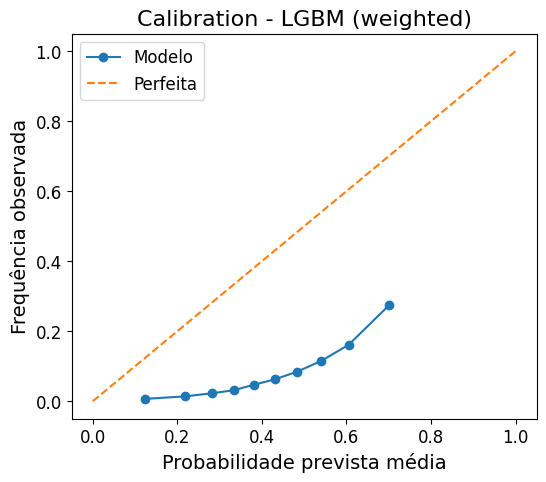

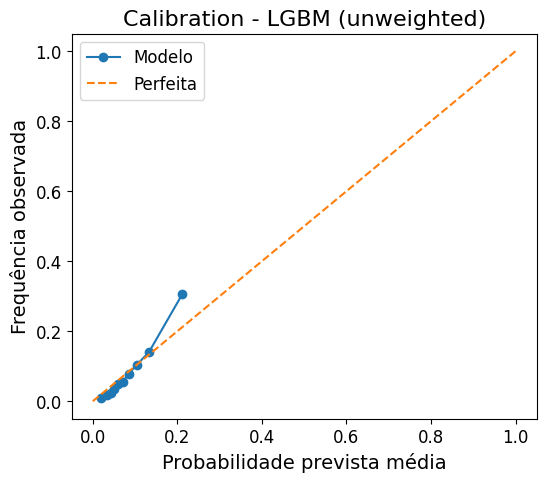

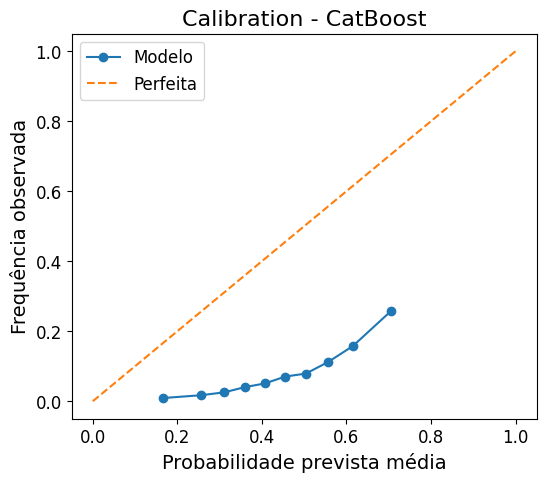

In [96]:
# ============================================================
# CÉLULA NOVA — DIAGNÓSTICO DE CALIBRAÇÃO
# ============================================================

print("Prevalência real na validação:", y_val.mean())
print("Média das probabilidades - LGBM com peso:", np.mean(y_val_proba_lgbm_weighted))
print("Média das probabilidades - LGBM sem peso:", np.mean(y_val_proba_lgbm_unweighted))
print("Média das probabilidades - CatBoost:", np.mean(y_val_proba_cat))

plot_calibration_diagnostic(y_val, y_val_proba_lgbm_weighted, "Calibration - LGBM (weighted)")
plot_calibration_diagnostic(y_val, y_val_proba_lgbm_unweighted, "Calibration - LGBM (unweighted)")
plot_calibration_diagnostic(y_val, y_val_proba_cat, "Calibration - CatBoost")

# Prevalência real na validação: 0.08196739553775106
# Média das probabilidades - LGBM com peso: 0.40980949341482
# Média das probabilidades - LGBM sem peso: 0.08110925513051452
# Média das probabilidades - CatBoost: 0.4337718847775573

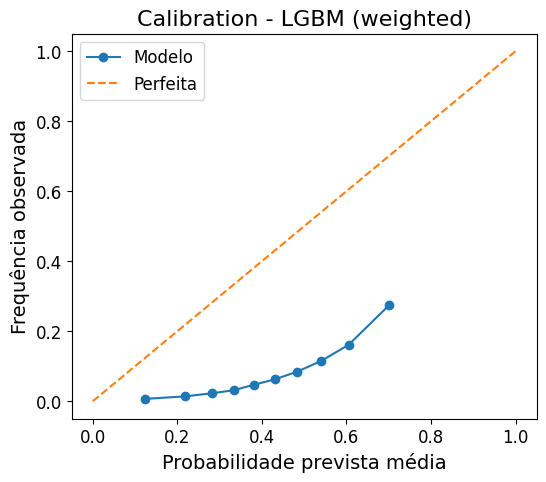

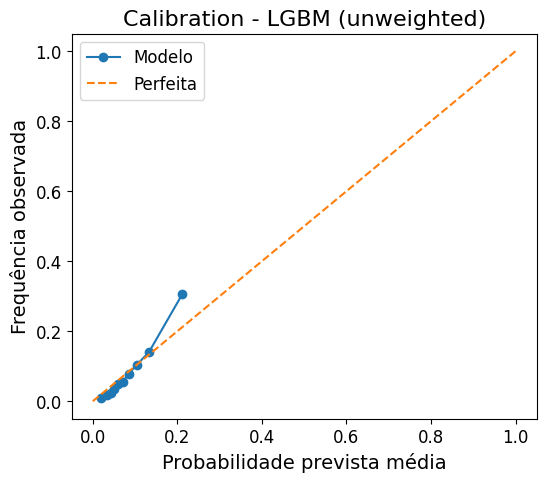

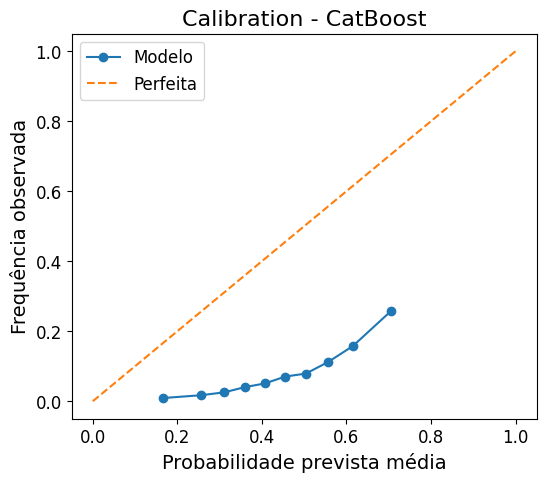

In [ ]:
# ============================================================
# CÉLULA NOVA — DIAGNÓSTICO DE CALIBRAÇÃO
# ============================================================

import matplotlib.pyplot as plt
import os

os.makedirs(OUTPUT_DIR, exist_ok=True)

# LGBM weighted
plot_calibration_diagnostic(y_val, y_val_proba_lgbm_weighted, "Calibration - LGBM (weighted)")
plt.savefig(os.path.join(OUTPUT_DIR, "calibration_lgbm_weighted.pdf"), dpi=300, bbox_inches="tight")
plt.close()

# LGBM unweighted
plot_calibration_diagnostic(y_val, y_val_proba_lgbm_unweighted, "Calibration - LGBM (unweighted)")
plt.savefig(os.path.join(OUTPUT_DIR, "calibration_lgbm_unweighted.pdf"), dpi=300, bbox_inches="tight")
plt.close()

# CatBoost
plot_calibration_diagnostic(y_val, y_val_proba_cat, "Calibration - CatBoost")
plt.savefig(os.path.join(OUTPUT_DIR, "calibration_catboost.pdf"), dpi=300, bbox_inches="tight")
plt.close()

In [ ]:
# ============================================================
# CÉLULA 11 — ESCOLHA DO MELHOR MODELO
# ============================================================

best_model_name = comparison_models.loc[0, "modelo"]

if best_model_name == "LightGBM_weighted":
    best_model = model_lgbm_weighted
    best_threshold = best_thr_lgbm_weighted

elif best_model_name == "LightGBM_unweighted":
    best_model = model_lgbm_unweighted
    best_threshold = best_thr_lgbm_unweighted

else:
    best_model = model_cat
    best_threshold = best_thr_cat

print("Melhor modelo preliminar na comparação inicial:", best_model_name)
print("Threshold escolhido:", best_threshold)

# Melhor modelo preliminar na comparação inicial: LightGBM_weighted
# Threshold escolhido: 0.5

Melhor modelo preliminar na comparação inicial: LightGBM_weighted
Threshold escolhido: 0.5


In [ ]:
# ============================================================
# CÉLULA 12 — PREPARAÇÃO FULL 2024 PARA TREINO FINAL
# ============================================================
# Objetivo:
# Recriar a base completa de treino (2024) e a base de teste temporal (2025), aplicando exatamente a mesma lógica usada na comparação:
# - rare grouping
# - clipping
# - remoção das colunas de alta cardinalidade
# - alinhamento exato da ordem das colunas
# ============================================================

X_full = X_trainval_prepared.copy()
y_full = y_trainval.copy()

X_test_base = X_test_prepared.copy()

# aplicar rare grouping
X_full_rare = apply_rare_maps(X_full, rare_maps)
X_test_rare = apply_rare_maps(X_test_base, rare_maps)

# aplicar clipping
X_full_clipped = apply_clip_bounds(X_full_rare, clip_bounds)
X_test_final = apply_clip_bounds(X_test_rare, clip_bounds)

# remover as mesmas colunas excluídas da comparação justa
X_full_common = X_full_clipped.drop(columns=common_drop_cols, errors="ignore").copy()
X_test_final_common = X_test_final.drop(columns=common_drop_cols, errors="ignore").copy()

# garantir que o teste tenha exatamente as mesmas colunas e na MESMA ORDEM do treino final
common_cols_final = X_full_common.columns.tolist()
X_test_final_common = X_test_final_common.reindex(columns=common_cols_final).copy()

print("Bases finais preparadas.")
print("X_full_common:", X_full_common.shape)
print("X_test_final_common:", X_test_final_common.shape)

# checagem adicional de alinhamento
print("Mesma ordem de colunas:", X_full_common.columns.tolist() == X_test_final_common.columns.tolist())

# Bases finais preparadas.
# X_full_common: (449323, 255)
# X_test_final_common: (431036, 255)
# Mesma ordem de colunas: True

Bases finais preparadas.
X_full_common: (449323, 255)
X_test_final_common: (431036, 255)
Mesma ordem de colunas: True


In [ ]:
# ============================================================
# Célula 20 — Tuning LightGBM com early stopping
# ============================================================

import gc
import numpy as np
import pandas as pd

from sklearn.model_selection import ParameterGrid
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from lightgbm import early_stopping, log_evaluation

# ------------------------------------------------------------
# 1. Reduce memory usage before tuning
# ------------------------------------------------------------
X_train_lgbm = X_train_lgbm.copy()
X_val_lgbm = X_val_lgbm.copy()

# Cast numeric columns to lighter dtypes
for col in X_train_lgbm.select_dtypes(include=["float64"]).columns:
    X_train_lgbm[col] = X_train_lgbm[col].astype("float32")
    if col in X_val_lgbm.columns:
        X_val_lgbm[col] = X_val_lgbm[col].astype("float32")

for col in X_train_lgbm.select_dtypes(include=["int64"]).columns:
    X_train_lgbm[col] = X_train_lgbm[col].astype("int32")
    if col in X_val_lgbm.columns:
        X_val_lgbm[col] = X_val_lgbm[col].astype("int32")

# Ensure categorical columns are stored as category dtype
valid_cat_cols = [col for col in cat_cols if col in X_train_lgbm.columns]

for col in valid_cat_cols:
    X_train_lgbm[col] = X_train_lgbm[col].astype("category")
    if col in X_val_lgbm.columns:
        X_val_lgbm[col] = X_val_lgbm[col].astype("category")

train_mem_mb = X_train_lgbm.memory_usage(deep=True).sum() / 1024**2
val_mem_mb = X_val_lgbm.memory_usage(deep=True).sum() / 1024**2

print(f"Train memory usage: {train_mem_mb:.2f} MB")
print(f"Validation memory usage: {val_mem_mb:.2f} MB")
print(f"Number of categorical columns used: {len(valid_cat_cols)}")

# ------------------------------------------------------------
# 2. Parameter grid
# ------------------------------------------------------------
param_grid = {
    "learning_rate": [0.03, 0.05],
    "num_leaves": [31, 63],
    "min_child_samples": [20, 40, 80],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "reg_alpha": [0.0, 0.5, 1.0],
    "reg_lambda": [1.0, 3.0]
}

all_params = list(ParameterGrid(param_grid))
print(f"Total parameter combinations: {len(all_params)}")

# ------------------------------------------------------------
# 3. Run tuning
# ------------------------------------------------------------
tuning_rows = []

for i, params in enumerate(all_params, start=1):
    print(f"[{i}/{len(all_params)}] Training with params: {params}")

    model = build_lgbm_model(
        scale_pos_weight=None,
        n_estimators=2000,
        **params
    )

    try:
        model.fit(
            X_train_lgbm,
            y_train,
            categorical_feature=valid_cat_cols,
            eval_set=[(X_val_lgbm, y_val)],
            eval_metric="average_precision",
            callbacks=[
                early_stopping(stopping_rounds=100, verbose=False),
                log_evaluation(period=0)
            ]
        )

        y_val_proba_tmp = model.predict_proba(X_val_lgbm)[:, 1]

        tuning_rows.append({
            **params,
            "auc_roc": roc_auc_score(y_val, y_val_proba_tmp),
            "auc_pr": average_precision_score(y_val, y_val_proba_tmp),
            "brier": brier_score_loss(y_val, y_val_proba_tmp),
            "best_iteration_": getattr(model, "best_iteration_", None)
        })

    except MemoryError:
        print(f"MemoryError with params: {params}")
        tuning_rows.append({
            **params,
            "auc_roc": np.nan,
            "auc_pr": np.nan,
            "brier": np.nan,
            "best_iteration_": np.nan
        })

    except Exception as e:
        print(f"Error with params {params}: {e}")
        tuning_rows.append({
            **params,
            "auc_roc": np.nan,
            "auc_pr": np.nan,
            "brier": np.nan,
            "best_iteration_": np.nan
        })

    finally:
        if "y_val_proba_tmp" in locals():
            del y_val_proba_tmp
        del model
        gc.collect()

# ------------------------------------------------------------
# 4. Organize results
# ------------------------------------------------------------
tuning_df = pd.DataFrame(tuning_rows).sort_values(
    by=["auc_pr", "auc_roc"],
    ascending=[False, False],
    na_position="last"
).reset_index(drop=True)

display(tuning_df.head(20))

# colsample_bytree	learning_rate	min_child_samples	num_leaves	reg_alpha	reg_lambda	subsample	auc_roc	auc_pr	brier	best_iteration_
# 0	0.8	0.05	20	63	0.0	1.0	0.8	0.918679	0.710288	0.049101	2000
# 1	0.8	0.05	20	63	0.0	1.0	1.0	0.918679	0.710288	0.049101	2000
# 2	0.8	0.05	40	63	0.0	1.0	0.8	0.915309	0.701155	0.049564	2000
# 3	0.8	0.05	40	63	0.0	1.0	1.0	0.915309	0.701155	0.049564	2000
# 4	1.0	0.05	40	63	0.0	1.0	0.8	0.917238	0.701075	0.049323	1997
# 5	1.0	0.05	40	63	0.0	1.0	1.0	0.917238	0.701075	0.049323	1997
# 6	1.0	0.05	80	63	0.0	1.0	0.8	0.916027	0.699459	0.049165	2000
# 7	1.0	0.05	80	63	0.0	1.0	1.0	0.916027	0.699459	0.049165	2000
# 8	1.0	0.05	20	63	0.5	1.0	0.8	0.915194	0.698962	0.049610	2000
# 9	1.0	0.05	20	63	0.5	1.0	1.0	0.915194	0.698962	0.049610	2000
# 10	0.8	0.05	20	63	0.5	1.0	0.8	0.916848	0.698796	0.049804	1999
# 11	0.8	0.05	20	63	0.5	1.0	1.0	0.916848	0.698796	0.049804	1999
# 12	0.8	0.05	80	63	0.0	1.0	0.8	0.914996	0.697413	0.049550	1999
# 13	0.8	0.05	80	63	0.0	1.0	1.0	0.914996	0.697413	0.049550	1999
# 14	1.0	0.05	20	63	0.0	1.0	0.8	0.913882	0.697041	0.049653	1998
# 15	1.0	0.05	20	63	0.0	1.0	1.0	0.913882	0.697041	0.049653	1998
# 16	1.0	0.05	80	63	0.5	1.0	0.8	0.915009	0.696560	0.049412	2000
# 17	1.0	0.05	80	63	0.5	1.0	1.0	0.915009	0.696560	0.049412	2000
# 18	0.8	0.05	80	63	1.0	1.0	0.8	0.916454	0.696371	0.049634	1999
# 19	0.8	0.05	80	63	1.0	1.0	1.0	0.916454	0.696371	0.049634	1999

#302m

Train memory usage: 138.56 MB
Validation memory usage: 34.69 MB
Number of categorical columns used: 208
Total parameter combinations: 288
[1/288] Training with params: {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'min_child_samples': 20, 'num_leaves': 31, 'reg_alpha': 0.0, 'reg_lambda': 1.0, 'subsample': 0.8}
[LightGBM] [Info] Number of positive: 29465, number of negative: 329993
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.053064 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4254
[LightGBM] [Info] Number of data points in the train set: 359458, number of used features: 215
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.081971 -> initscore=-2.415868
[LightGBM] [Info] Start training from score -2.415868
[2/288] Training with params: {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'min_child_samples': 20, 'num_leaves': 31, 'r

,colsample_bytree,learning_rate,min_child_samples,num_leaves,reg_alpha,reg_lambda,subsample,auc_roc,auc_pr,brier,best_iteration_
0,0.8,0.05,20,63,0.0,1.0,0.8,0.918679,0.710288,0.049101,2000
1,0.8,0.05,20,63,0.0,1.0,1.0,0.918679,0.710288,0.049101,2000
2,0.8,0.05,40,63,0.0,1.0,0.8,0.915309,0.701155,0.049564,2000
3,0.8,0.05,40,63,0.0,1.0,1.0,0.915309,0.701155,0.049564,2000
4,1.0,0.05,40,63,0.0,1.0,0.8,0.917238,0.701075,0.049323,1997
5,1.0,0.05,40,63,0.0,1.0,1.0,0.917238,0.701075,0.049323,1997
6,1.0,0.05,80,63,0.0,1.0,0.8,0.916027,0.699459,0.049165,2000
7,1.0,0.05,80,63,0.0,1.0,1.0,0.916027,0.699459,0.049165,2000
8,1.0,0.05,20,63,0.5,1.0,0.8,0.915194,0.698962,0.049610,2000
9,1.0,0.05,20,63,0.5,1.0,1.0,0.915194,0.698962,0.049610,2000


In [167]:
# ============================================================
#Célula 21 — Seleção dos melhores parâmetros
# ============================================================

if tuning_df.empty:
    raise ValueError("tuning_df está vazio.")

best_row = tuning_df.iloc[0].copy()

best_lgbm_params = {
    "learning_rate": float(best_row["learning_rate"]),
    "num_leaves": int(best_row["num_leaves"]),
    "min_child_samples": int(best_row["min_child_samples"]),
    "subsample": float(best_row["subsample"]),
    "colsample_bytree": float(best_row["colsample_bytree"]),
    "reg_alpha": float(best_row["reg_alpha"]),
    "reg_lambda": float(best_row["reg_lambda"])
}

best_n_estimators = int(best_row["best_iteration_"]) if pd.notna(best_row["best_iteration_"]) else 2000

print("Melhores hiperparâmetros:")
print(best_lgbm_params)
print("Best iteration:", best_n_estimators)

# Melhores hiperparâmetros:
# {'learning_rate': 0.05, 'num_leaves': 63, 'min_child_samples': 20, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.0, 'reg_lambda': 1.0}
# Best iteration: 2000

Melhores hiperparâmetros:
{'learning_rate': 0.05, 'num_leaves': 63, 'min_child_samples': 20, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.0, 'reg_lambda': 1.0}
Best iteration: 2000


In [168]:
# ============================================================
# Células 22 e 23 — Comparação unweighted vs weighted
# ============================================================

from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from lightgbm import early_stopping, log_evaluation

comparison_rows = []

neg_train = (y_train == 0).sum()
pos_train = (y_train == 1).sum()
spw = neg_train / max(pos_train, 1)

for variant_name, current_spw in [
    ("unweighted", 1.0),
    ("weighted", spw)
]:
    print("=" * 70)
    print("Treinando variante:", variant_name)

    model_tmp = build_lgbm_model(
        scale_pos_weight=current_spw,
        n_estimators=2000,
        **best_lgbm_params
    )

    model_tmp.fit(
        X_train_lgbm,
        y_train,
        categorical_feature=valid_cat_cols,
        eval_set=[(X_val_lgbm, y_val)],
        eval_metric="average_precision",
        callbacks=[
            early_stopping(stopping_rounds=100, verbose=False),
            log_evaluation(period=0)
        ]
    )

    y_val_proba_tmp = model_tmp.predict_proba(X_val_lgbm)[:, 1]

    comparison_rows.append({
        "model_base": "LightGBM",
        "variant": variant_name,
        "scale_pos_weight": current_spw,
        "auc_roc": roc_auc_score(y_val, y_val_proba_tmp),
        "auc_pr": average_precision_score(y_val, y_val_proba_tmp),
        "brier": brier_score_loss(y_val, y_val_proba_tmp),
        "mean_pred": float(np.mean(y_val_proba_tmp)),
        "best_iteration_": getattr(model_tmp, "best_iteration_", None)
    })

comparison_weight_df = pd.DataFrame(comparison_rows).sort_values(
    by=["auc_pr", "auc_roc", "brier"],
    ascending=[False, False, True]
).reset_index(drop=True)

display(comparison_weight_df)

best_model_name = "LightGBM"
best_variant = comparison_weight_df.iloc[0]["variant"]
best_scale_pos_weight = comparison_weight_df.iloc[0]["scale_pos_weight"]

print("Melhor modelo base:", best_model_name)
print("Melhor variante:", best_variant)
print("Melhor scale_pos_weight:", best_scale_pos_weight)

# 	model_base	variant	scale_pos_weight	auc_roc	auc_pr	brier	mean_pred	best_iteration_
# 0	LightGBM	unweighted	1.000000	0.918679	0.710288	0.049101	0.069654	2000
# 1	LightGBM	weighted	11.199491	0.661760	0.138082	0.075039	0.103593	1

# Melhor modelo base: LightGBM
# Melhor variante: unweighted
# Melhor scale_pos_weight: 1.0

Treinando variante: unweighted
[LightGBM] [Info] Number of positive: 29465, number of negative: 329993
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.078133 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4254
[LightGBM] [Info] Number of data points in the train set: 359458, number of used features: 215
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.081971 -> initscore=-2.415868
[LightGBM] [Info] Start training from score -2.415868
Treinando variante: weighted
[LightGBM] [Info] Number of positive: 29465, number of negative: 329993
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.074703 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4254
[LightGBM] [Info] Number of data points in the 

,model_base,variant,scale_pos_weight,auc_roc,auc_pr,brier,mean_pred,best_iteration_
0,LightGBM,unweighted,1.000000,0.918679,0.710288,0.049101,0.069654,2000
1,LightGBM,weighted,11.199491,0.661760,0.138082,0.075039,0.103593,1


Melhor modelo base: LightGBM
Melhor variante: unweighted
Melhor scale_pos_weight: 1.0


In [195]:
# ============================================================
# CÉLULA — DECISÃO FINAL CORRETA
# ============================================================

best_model_name = "LightGBM"
best_variant = comparison_weight_df.iloc[0]["variant"]
best_scale_pos_weight = comparison_weight_df.iloc[0]["scale_pos_weight"]

if best_variant == "unweighted":
    best_threshold = best_thr_lgbm_unweighted
elif best_variant == "weighted":
    best_threshold = best_thr_lgbm_weighted
else:
    raise ValueError(f"Variante inesperada: {best_variant}")

print("Decisão final:")
print("best_model_name      :", best_model_name)
print("best_variant         :", best_variant)
print("best_scale_pos_weight:", best_scale_pos_weight)
print("best_threshold       :", best_threshold)

# ============================================================
# CÉLULA — DECISÃO FINAL CORRETA
# ============================================================

best_model_name = "LightGBM"
best_variant = comparison_weight_df.iloc[0]["variant"]
best_scale_pos_weight = comparison_weight_df.iloc[0]["scale_pos_weight"]

if best_variant == "unweighted":
    best_threshold = best_thr_lgbm_unweighted
elif best_variant == "weighted":
    best_threshold = best_thr_lgbm_weighted
else:
    raise ValueError(f"Variante inesperada: {best_variant}")

# print("Decisão final:")
# print("best_model_name      :", best_model_name)
# print("best_variant         :", best_variant)
# print("best_scale_pos_weight:", best_scale_pos_weight)
# print("best_threshold       :", best_threshold)

Decisão final:
best_model_name      : LightGBM
best_variant         : unweighted
best_scale_pos_weight: 1.0
best_threshold       : 0.09


In [192]:
# ============================================================
# Célula 25 — Checagem
# ============================================================

print(comparison_weight_df)

assert best_model_name == "LightGBM"
assert best_variant in ["unweighted", "weighted"]

# model_base     variant  scale_pos_weight   auc_roc    auc_pr     brier  \
# 0   LightGBM  unweighted          1.000000  0.918679  0.710288  0.049101   
# 1   LightGBM    weighted         11.199491  0.661760  0.138082  0.075039   

#    mean_pred  best_iteration_  
# 0   0.069654             2000  
# 1   0.103593                1 

  model_base     variant  scale_pos_weight   auc_roc    auc_pr     brier  \
0   LightGBM  unweighted          1.000000  0.918679  0.710288  0.049101   
1   LightGBM    weighted         11.199491  0.661760  0.138082  0.075039   

   mean_pred  best_iteration_  
0   0.069654             2000  
1   0.103593                1  


In [ ]:
# ============================================================
# Célula 27 — Treino final do melhor modelo
# ============================================================
# Objetivo:
# Re-treinar o melhor modelo usando todo o conjunto de 2024 e preparar corretamente a base de teste temporal de 2025.
# ============================================================

from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import pandas as pd

if best_model_name == "LightGBM":
    # --------------------------------------------------------
    # PREPARAÇÃO FINAL PARA LIGHTGBM
    # --------------------------------------------------------
    X_full_final = X_full_common.copy()
    X_test_final  = X_test_final_common.copy()

    cat_cols_full = X_full_final.select_dtypes(
        include=["object", "string", "category"]
    ).columns.tolist()

    for c in cat_cols_full:
        X_full_final[c] = X_full_final[c].astype("string")
        X_test_final [c]  = X_test_final [c].astype("string")

    # categorias definidas apenas com base no treino final
    for c in cat_cols_full:
        train_cats = pd.Index(
            X_full_final[c].dropna().unique().tolist()
        ).unique()

        X_full_final[c] = pd.Categorical(X_full_final[c], categories=train_cats)
        X_test_final [c]  = pd.Categorical(X_test_final [c], categories=train_cats)

    final_model = LGBMClassifier(
        objective="binary",
        boosting_type="gbdt",
        n_estimators=2000,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        scale_pos_weight=best_scale_pos_weight,
        **best_lgbm_params
    )

    final_model.fit(
        X_full_final,
        y_full,
        categorical_feature=cat_cols_full
    )

else:
    # --------------------------------------------------------
    # PREPARAÇÃO FINAL PARA CATBOOST
    # --------------------------------------------------------
    X_full_final = X_full_common.copy()
    X_test_eval = X_test_final_common.copy()

    cat_cols_full = X_full_final.select_dtypes(
        include=["object", "string", "category"]
    ).columns.tolist()

    for c in cat_cols_full:
        X_full_final[c] = X_full_final[c].astype("object")
        X_test_eval[c]  = X_test_eval[c].astype("object")

        X_full_final[c] = X_full_final[c].where(
            pd.notna(X_full_final[c]), "__MISSING__"
        ).map(str)

        X_test_eval[c] = X_test_eval[c].where(
            pd.notna(X_test_eval[c]), "__MISSING__"
        ).map(str)

    cat_features_idx_full = [
        X_full_final.columns.get_loc(c) for c in cat_cols_full
    ]

    assert X_full_final.dtypes.equals(X_test_eval.dtypes), \
        "Os dtypes entre treino final e teste final do CatBoost não estão alinhados."

    final_model = CatBoostClassifier(
        loss_function="Logloss",
        eval_metric="AUC",
        iterations=400,
        learning_rate=0.05,
        depth=6,
        l2_leaf_reg=5,
        random_seed=RANDOM_STATE,
        verbose=False,
        auto_class_weights="Balanced"
    )

    final_model.fit(
        X_full_final,
        y_full,
        cat_features=cat_features_idx_full
    )

print(f"Modelo final treinado: {best_model_name}")
print(f"Variante final: {best_variant}")
print(f"scale_pos_weight final: {best_scale_pos_weight}")
print("Shape treino final:", X_full_final.shape)
print("Shape teste final :", X_test_final.shape)
print("Mesma ordem de colunas:", X_full_final.columns.tolist() == X_test_final.columns.tolist())


[LightGBM] [Info] Number of positive: 36831, number of negative: 412492
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.088724 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4277
[LightGBM] [Info] Number of data points in the train set: 449323, number of used features: 217
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.081970 -> initscore=-2.415877
[LightGBM] [Info] Start training from score -2.415877
Modelo final treinado: LightGBM
Variante final: unweighted
scale_pos_weight final: 1.0
Shape treino final: (449323, 255)
Shape teste final : (431036, 255)
Mesma ordem de colunas: True


In [ ]:
# ===========================
# Célula 28 — Print do modelo final
# ===========================

print("Modelo:", best_model_name)
print("Variante:", best_variant)
print("scale_pos_weight:", best_scale_pos_weight)
print("Threshold:", best_threshold)

# Modelo: LightGBM
# Variante: unweighted
# scale_pos_weight: 1.0
# Threshold: 0.09

Modelo: LightGBM
Variante: unweighted
scale_pos_weight: 1.0
Threshold: 0.09


In [ ]:
# ============================================================
# Célula 29 — Avaliação final em 2025
# ============================================================
# Objetivo:
# Avaliar o melhor modelo final treinado em 2024 sobre o teste temporal real de 2025.
# ============================================================

import pandas as pd

y_test_proba_final = final_model.predict_proba(X_test_final)[:, 1]

test_results_final, y_test_pred_final = evaluate_binary_model(
    y_true=y_test,
    y_proba=y_test_proba_final,
    threshold=best_threshold,
    model_name=f"{best_model_name}_{best_variant}",
    dataset_name="test_2025"
)

test_results_df = pd.DataFrame([test_results_final])

print("Resultados finais no teste temporal (2025):")
display(test_results_df)

print("Resumo das probabilidades preditas:")
display(pd.Series(y_test_proba_final).describe())

# 	dataset	modelo	threshold	accuracy	precision	recall	f1	f2	auc_roc	auc_pr	brier
# 0	test_2025	LightGBM_unweighted	0.09	0.883803	0.400372	0.783124	0.529855	0.657425	0.908349	0.723166	0.04878
# Resumo das probabilidades preditas:
# count    431036.000000
# mean          0.063785
# std           0.106802
# min           0.000087
# 25%           0.015107
# 50%           0.031904
# 75%           0.064999
# max           0.970148


Resultados finais no teste temporal (2025):


,dataset,modelo,threshold,accuracy,precision,recall,f1,f2,auc_roc,auc_pr,brier
0,test_2025,LightGBM_unweighted,0.09,0.883803,0.400372,0.783124,0.529855,0.657425,0.908349,0.723166,0.04878


Resumo das probabilidades preditas:


count    431036.000000
mean          0.063785
std           0.106802
min           0.000087
25%           0.015107
50%           0.031904
75%           0.064999
max           0.970148
dtype: float64

In [ ]:
# ============================================================
# Célula 30 — Base individual de predições 2025
# ============================================================
# Objetivo:
# Criar a base individual com código do município, probabilidade predita e rótulo verdadeiro para cada registro de 2025.
# ============================================================

import pandas as pd

df_pred_2025 = pd.DataFrame({
    "cd_ibge": X_test_eval["d.cd_ibge"].astype(str).str.replace(r"\.0$", "", regex=True),
    "prob_risco": y_test_proba_final,
    "y_true": y_test
})

print("Shape da base individual:", df_pred_2025.shape)
print("Número de municípios únicos:", df_pred_2025["cd_ibge"].nunique())
display(df_pred_2025.head())

# 	cd_ibge	prob_risco	y_true
# 4020199	2705804	0.017786	0
# 4020200	2705804	0.019801	0
# 4020201	2705804	0.020884	0
# 4020205	2705804	0.011057	0
# 4020206	2705804	0.010717	0


# Shape da base individual: (431036, 3)
# Número de municípios únicos: 100

Shape da base individual: (431036, 3)
Número de municípios únicos: 100


,cd_ibge,prob_risco,y_true
4020199,2705804,0.017786,0
4020200,2705804,0.019801,0
4020201,2705804,0.020884,0
4020205,2705804,0.011057,0
4020206,2705804,0.010717,0


In [ ]:
# ============================================================
# CÉLULA 31 — AGREGAÇÃO MUNICIPAL DO RISCO EM 2025
# ============================================================
# Objetivo:
# Agregar as probabilidades preditas ao nível municipal.
# ============================================================

risk_2025 = (
    df_pred_2025
    .groupby("cd_ibge", as_index=False)
    .agg(
        risco_medio=("prob_risco", "mean"),
        prevalencia_observada=("y_true", "mean"),
        n_familias=("prob_risco", "size")
    )
)

print("Base municipal criada com sucesso.")
print("Shape:", risk_2025.shape)
display(risk_2025.head())
display(risk_2025.sort_values("risco_medio", ascending=False).head(10))


# ============================================================
# CÉLULA 31 — AGREGAÇÃO MUNICIPAL DO RISCO EM 2025
# ============================================================
# Objetivo:
# Agregar as probabilidades preditas ao nível municipal.
# ============================================================

risk_2025 = (
    df_pred_2025
    .groupby("cd_ibge", as_index=False)
    .agg(
        risco_medio=("prob_risco", "mean"),
        prevalencia_observada=("y_true", "mean"),
        n_familias=("prob_risco", "size")
    )
)

print("Base municipal criada com sucesso.")
print("Shape:", risk_2025.shape)
display(risk_2025.head())
display(risk_2025.sort_values("risco_medio", ascending=False).head(10))


# Base municipal criada com sucesso.
# Shape: (100, 4)
# cd_ibge	risco_medio	prevalencia_observada	n_familias
# 0	2700201	0.032422	0.039131	5341
# 1	2700300	0.052419	0.064951	22109
# 2	2700409	0.042079	0.048336	6910
# 3	2700508	0.071714	0.096008	2104
# 4	2700607	0.035360	0.046185	996

# cd_ibge	risco_medio	prevalencia_observada	n_familias
# 63	2706109	0.193251	0.247283	4509
# 59	2705705	0.153804	0.223266	2768
# 67	2706422	0.136064	0.210724	1865
# 83	2707909	0.123042	0.163337	851
# 56	2705408	0.122011	0.157451	2134
# 35	2703403	0.120279	0.141482	2389
# 36	2703502	0.117910	0.218341	687
# 29	2702801	0.110511	0.130207	3049
# 71	2706703	0.108475	0.129903	10708
# 48	2704609	0.108090	0.134083	3289
# Base municipal criada com sucesso.

# Shape: (100, 4)
# cd_ibge	risco_medio	prevalencia_observada	n_familias
# 0	2700201	0.032422	0.039131	5341
# 1	2700300	0.052419	0.064951	22109
# 2	2700409	0.042079	0.048336	6910
# 3	2700508	0.071714	0.096008	2104
# 4	2700607	0.035360	0.046185	996

# cd_ibge	risco_medio	prevalencia_observada	n_familias
# 63	2706109	0.193251	0.247283	4509
# 59	2705705	0.153804	0.223266	2768
# 67	2706422	0.136064	0.210724	1865
# 83	2707909	0.123042	0.163337	851
# 56	2705408	0.122011	0.157451	2134
# 35	2703403	0.120279	0.141482	2389
# 36	2703502	0.117910	0.218341	687
# 29	2702801	0.110511	0.130207	3049
# 71	2706703	0.108475	0.129903	10708
# 48	2704609	0.108090	0.134083	3289


Base municipal criada com sucesso.
Shape: (100, 4)


,cd_ibge,risco_medio,prevalencia_observada,n_familias
0,2700201,0.032422,0.039131,5341
1,2700300,0.052419,0.064951,22109
2,2700409,0.042079,0.048336,6910
3,2700508,0.071714,0.096008,2104
4,2700607,0.035360,0.046185,996


,cd_ibge,risco_medio,prevalencia_observada,n_familias
63,2706109,0.193251,0.247283,4509
59,2705705,0.153804,0.223266,2768
67,2706422,0.136064,0.210724,1865
83,2707909,0.123042,0.163337,851
56,2705408,0.122011,0.157451,2134
35,2703403,0.120279,0.141482,2389
36,2703502,0.117910,0.218341,687
29,2702801,0.110511,0.130207,3049
71,2706703,0.108475,0.129903,10708
48,2704609,0.108090,0.134083,3289


Base municipal criada com sucesso.
Shape: (100, 4)


,cd_ibge,risco_medio,prevalencia_observada,n_familias
0,2700201,0.032422,0.039131,5341
1,2700300,0.052419,0.064951,22109
2,2700409,0.042079,0.048336,6910
3,2700508,0.071714,0.096008,2104
4,2700607,0.035360,0.046185,996


,cd_ibge,risco_medio,prevalencia_observada,n_familias
63,2706109,0.193251,0.247283,4509
59,2705705,0.153804,0.223266,2768
67,2706422,0.136064,0.210724,1865
83,2707909,0.123042,0.163337,851
56,2705408,0.122011,0.157451,2134
35,2703403,0.120279,0.141482,2389
36,2703502,0.117910,0.218341,687
29,2702801,0.110511,0.130207,3049
71,2706703,0.108475,0.129903,10708
48,2704609,0.108090,0.134083,3289


In [ ]:
# ============================================================
# CÉLULA 32 — PADRONIZAÇÃO E DIAGNÓSTICO
# ============================================================
# Objetivo:
# Padronizar os códigos municipais e identificar municípios presentes no shapefile, mas sem registros no teste de 2025.
# ============================================================

gdf = gdf.copy()
risk_2025 = risk_2025.copy()

gdf["CD_MUN"] = gdf["CD_MUN"].astype(str).str.replace(r"\.0$", "", regex=True)
risk_2025["cd_ibge"] = risk_2025["cd_ibge"].astype(str).str.replace(r"\.0$", "", regex=True)

codigos_shape = set(gdf["CD_MUN"])
codigos_risco = set(risk_2025["cd_ibge"])

faltantes = codigos_shape - codigos_risco

print("Municípios no shapefile:", len(codigos_shape))
print("Municípios com risco calculado:", len(codigos_risco))
print("Municípios sem registros em 2025:", len(faltantes))

faltantes_df = (
    gdf.loc[gdf["CD_MUN"].isin(faltantes), ["CD_MUN", "NM_MUN"]]
    .drop_duplicates()
    .sort_values("NM_MUN")
)

display(faltantes_df)

# Municípios no shapefile: 102
# Municípios com risco calculado: 100
# Municípios sem registros em 2025: 2
# CD_MUN	NM_MUN
# 2318	2709400	Viçosa
# 212	2700102	Água Branca


Municípios no shapefile: 102
Municípios com risco calculado: 100
Municípios sem registros em 2025: 2


,CD_MUN,NM_MUN
2318,2709400,Viçosa
212,2700102,Água Branca


In [ ]:
# ============================================================
# CÉLULA 33 — JUNÇÃO COM O SHAPEFILE
# ============================================================
# Objetivo:
# Associar o risco municipal à malha geográfica de Alagoas.
# ============================================================

gdf_risco_2025 = gdf.merge(
    risk_2025,
    left_on="CD_MUN",
    right_on="cd_ibge",
    how="left"
)

print("Municípios no shapefile:", len(gdf_risco_2025))
print("Municípios com risco associado:", gdf_risco_2025["risco_medio"].notna().sum())
print("Municípios sem risco associado:", gdf_risco_2025["risco_medio"].isna().sum())

display(
    gdf_risco_2025[
        ["CD_MUN", "NM_MUN", "risco_medio", "prevalencia_observada", "n_familias"]
    ].head()
)

# Municípios no shapefile: 102
# Municípios com risco associado: 100
# Municípios sem risco associado: 2

# CD_MUN	NM_MUN	risco_medio	prevalencia_observada	n_familias
# 0	2708600	São Miguel dos Campos	0.039752	0.047739	796.0
# 1	2701407	Campo Alegre	0.024281	0.032480	5819.0
# 2	2700102	Água Branca	NaN	NaN	NaN
# 3	2703205	Igreja Nova	0.055862	0.067520	3673.0
# 4	2709103	Taquarana	0.044782	0.075266	3667.0


Municípios no shapefile: 102
Municípios com risco associado: 100
Municípios sem risco associado: 2


,CD_MUN,NM_MUN,risco_medio,prevalencia_observada,n_familias
0,2708600,São Miguel dos Campos,0.039752,0.047739,796.0
1,2701407,Campo Alegre,0.024281,0.032480,5819.0
2,2700102,Água Branca,NaN,NaN,NaN
3,2703205,Igreja Nova,0.055862,0.067520,3673.0
4,2709103,Taquarana,0.044782,0.075266,3667.0


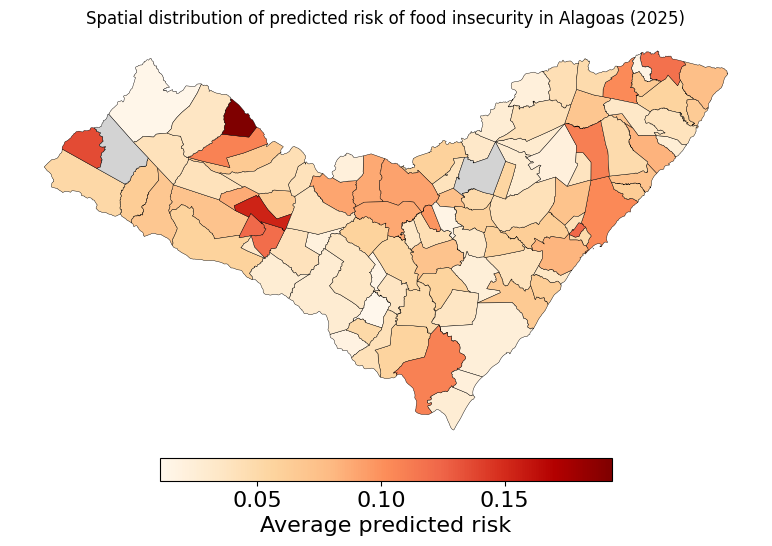

In [203]:
# ============================================================
# CÉLULA 34 — MAPA DO RISCO PREDITO EM 2025
# ============================================================
# Objetivo:
# Visualizar a distribuição espacial do risco médio predito.
# Municípios sem registros em 2025 permanecem como "Sem dados".
# ============================================================

import os
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 10))

gdf_risco_2025.plot(
    column="risco_medio",
    cmap="OrRd",
    linewidth=0.3,
    edgecolor="black",
    legend=True,
    legend_kwds={
        "orientation": "horizontal",
        "label": "Average predicted risk",
        "shrink": 0.6,
        "fraction": 0.05,
        "pad": 0.01
    },
    missing_kwds={
        "color": "lightgrey",
        "label": "No data"
    },
    ax=ax
)

ax.set_title("Spatial distribution of predicted risk of food insecurity in Alagoas (2025)", fontsize=12)
ax.axis("off")

plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, "mapa_risco_municipal_2025.pdf"),
    bbox_inches="tight"
)
plt.show()

In [ ]:
# ============================================================
# CÉLULA 35 — RANKING MUNICIPAL
# ============================================================
# Objetivo:
# Identificar os municípios com maior e menor risco médio predito.
# ============================================================

ranking_maior_risco = (
    risk_2025
    .sort_values("risco_medio", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

ranking_menor_risco = (
    risk_2025
    .sort_values("risco_medio", ascending=True)
    .head(10)
    .reset_index(drop=True)
)

print("Top 10 municipalities with the highest predicted risk:")
display(ranking_maior_risco)

print("Top 10 municipalities with the lowest predicted risk:")
display(ranking_menor_risco)


# Top 10 municipalities with the highest predicted risk:
# cd_ibge	risco_medio	prevalencia_observada	n_familias
# 0	2706109	0.193251	0.247283	4509
# 1	2705705	0.153804	0.223266	2768
# 2	2706422	0.136064	0.210724	1865
# 3	2707909	0.123042	0.163337	851
# 4	2705408	0.122011	0.157451	2134
# 5	2703403	0.120279	0.141482	2389
# 6	2703502	0.117910	0.218341	687
# 7	2702801	0.110511	0.130207	3049
# 8	2706703	0.108475	0.129903	10708
# 9	2704609	0.108090	0.134083	3289

# Top 10 municipalities with the lowest predicted risk:
# cd_ibge	risco_medio	prevalencia_observada	n_familias
# 0	2701506	0.010739	0.011225	3118
# 1	2705002	0.013009	0.017564	2562
# 2	2704104	0.015415	0.008499	3412
# 3	2709004	0.015724	0.007097	2677
# 4	2701357	0.016139	0.023791	1303
# 5	2708204	0.018109	0.006617	1209
# 6	2703700	0.020603	0.007445	2552
# 7	2705507	0.020833	0.027871	4485
# 8	2705309	0.021554	0.005805	1895
# 9	2708303	0.021560	0.032074	4739



Top 10 municipalities with the highest predicted risk:


,cd_ibge,risco_medio,prevalencia_observada,n_familias
0,2706109,0.193251,0.247283,4509
1,2705705,0.153804,0.223266,2768
2,2706422,0.136064,0.210724,1865
3,2707909,0.123042,0.163337,851
4,2705408,0.122011,0.157451,2134
5,2703403,0.120279,0.141482,2389
6,2703502,0.117910,0.218341,687
7,2702801,0.110511,0.130207,3049
8,2706703,0.108475,0.129903,10708
9,2704609,0.108090,0.134083,3289


Top 10 municipalities with the lowest predicted risk:


,cd_ibge,risco_medio,prevalencia_observada,n_familias
0,2701506,0.010739,0.011225,3118
1,2705002,0.013009,0.017564,2562
2,2704104,0.015415,0.008499,3412
3,2709004,0.015724,0.007097,2677
4,2701357,0.016139,0.023791,1303
5,2708204,0.018109,0.006617,1209
6,2703700,0.020603,0.007445,2552
7,2705507,0.020833,0.027871,4485
8,2705309,0.021554,0.005805,1895
9,2708303,0.021560,0.032074,4739


In [205]:
# ============================================================
# CÉLULA 36 — SALVAR ARTEFATOS FINAIS
# ============================================================
# Objetivo:
# Salvar as saídas principais da avaliação temporal e espacial.
# ============================================================

test_results_df.to_csv(
    os.path.join(OUTPUT_DIR, "test_results_2025_final.csv"),
    index=False
)

df_pred_2025.to_csv(
    os.path.join(OUTPUT_DIR, "predicoes_individuais_2025.csv"),
    index=False
)

risk_2025.to_csv(
    os.path.join(OUTPUT_DIR, "municipal_risk_2025.csv"),
    index=False
)

ranking_maior_risco.to_csv(
    os.path.join(OUTPUT_DIR, "ranking_maior_risco_2025.csv"),
    index=False
)

ranking_menor_risco.to_csv(
    os.path.join(OUTPUT_DIR, "ranking_menor_risco_2025.csv"),
    index=False
)

print("Artefatos finais salvos com sucesso.")

Artefatos finais salvos com sucesso.


In [ ]:
import geopandas as gpd

gdf = gpd.read_file(r"C:\Users\keila\Documents\CSBC2026\CRIA\data\BR_Municipios_2024\BR_Municipios_2024.shp")

# filtrar apenas Alagoas
gdf = gdf[gdf["SIGLA_UF"] == "AL"].copy()

print("Número de municípios em AL no shapefile:", len(gdf))
print(gdf[["CD_MUN", "NM_MUN", "SIGLA_UF"]].head())

# Número de municípios em AL no shapefile: 102
#       CD_MUN                 NM_MUN SIGLA_UF
# 4    2708600  São Miguel dos Campos       AL
# 23   2701407           Campo Alegre       AL
# 212  2700102            Água Branca       AL
# 240  2703205            Igreja Nova       AL
# 284  2709103              Taquarana       AL

Número de municípios em AL no shapefile: 102
      CD_MUN                 NM_MUN SIGLA_UF
4    2708600  São Miguel dos Campos       AL
23   2701407           Campo Alegre       AL
212  2700102            Água Branca       AL
240  2703205            Igreja Nova       AL
284  2709103              Taquarana       AL


In [207]:
gdf["CD_MUN"] = gdf["CD_MUN"].astype(str).str.replace(r"\.0$", "", regex=True)
risk_2025["cd_ibge"] = risk_2025["cd_ibge"].astype(str).str.replace(r"\.0$", "", regex=True)

gdf_risco_2025 = gdf.merge(
    risk_2025,
    left_on="CD_MUN",
    right_on="cd_ibge",
    how="left"
)

print("Municípios de AL no shapefile:", len(gdf))
print("Municípios com risco associado:", gdf_risco_2025["risco_medio"].notna().sum())

faltantes = gdf_risco_2025.loc[gdf_risco_2025["risco_medio"].isna(), ["CD_MUN", "NM_MUN"]]
print("Municípios sem risco associado:")
print(faltantes)

# Municípios de AL no shapefile: 102
# Municípios com risco associado: 100
# Municípios sem risco associado:
#      CD_MUN       NM_MUN
# 2   2700102  Água Branca
# 40  2709400       Viçosa

Municípios de AL no shapefile: 102
Municípios com risco associado: 100
Municípios sem risco associado:
     CD_MUN       NM_MUN
2   2700102  Água Branca
40  2709400       Viçosa


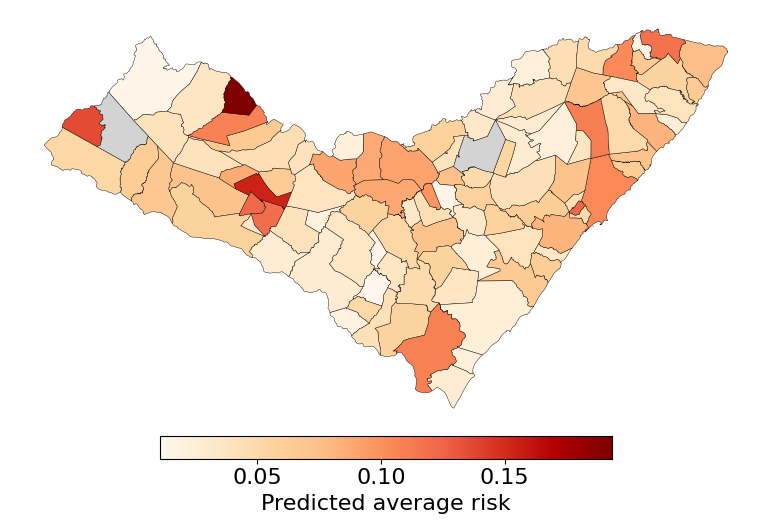

In [216]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 10))

gdf_risco_2025.plot(
    column="risco_medio",
    cmap="OrRd",
    linewidth=0.3,
    edgecolor="black",
    legend=True,
    legend_kwds={
        "orientation": "horizontal",
        "label": "Predicted average risk",
        "shrink": 0.6,  # opcional (tamanho da barra)
        "fraction": 0.04,   # altura da barra
        "pad": 0.01         # distância do mapa
    },
    missing_kwds={
        "color": "lightgrey",
        "label": "Sem dados"
    },
    ax=ax
)

ax.axis("off")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "mapa_risco_2025_1.pdf"), bbox_inches="tight")
plt.show()


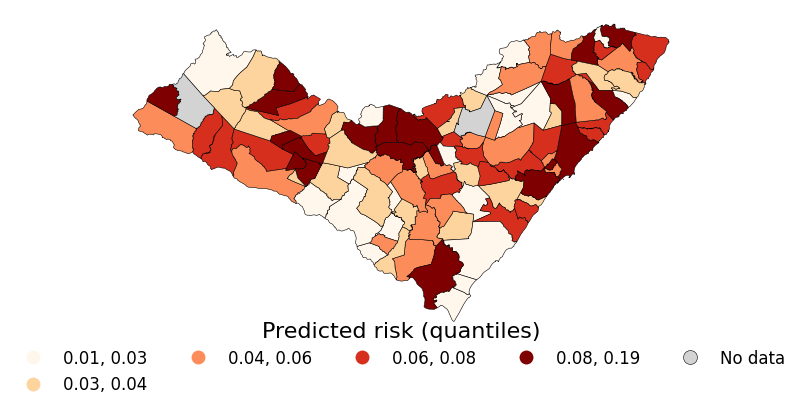

In [218]:
fig, ax = plt.subplots(figsize=(8, 10))

gdf_risco_2025.plot(
    column="risco_medio",
    cmap="OrRd",
    scheme="Quantiles",
    k=5,
    linewidth=0.4,
    edgecolor="black",
    legend=True,
    legend_kwds={
        "loc": "lower center",
        "bbox_to_anchor": (0.5, -0.22),  # empurra pra fora
        "ncol": 5,                       # uma linha só
        "title": "Predicted risk (quantiles)",
        "frameon": False,
    },
    missing_kwds={
        "color": "lightgrey",
        "label": "No data"
    },
    ax=ax
)

ax.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "mapa_risco_2025.pdf"), bbox_inches="tight")
plt.show()

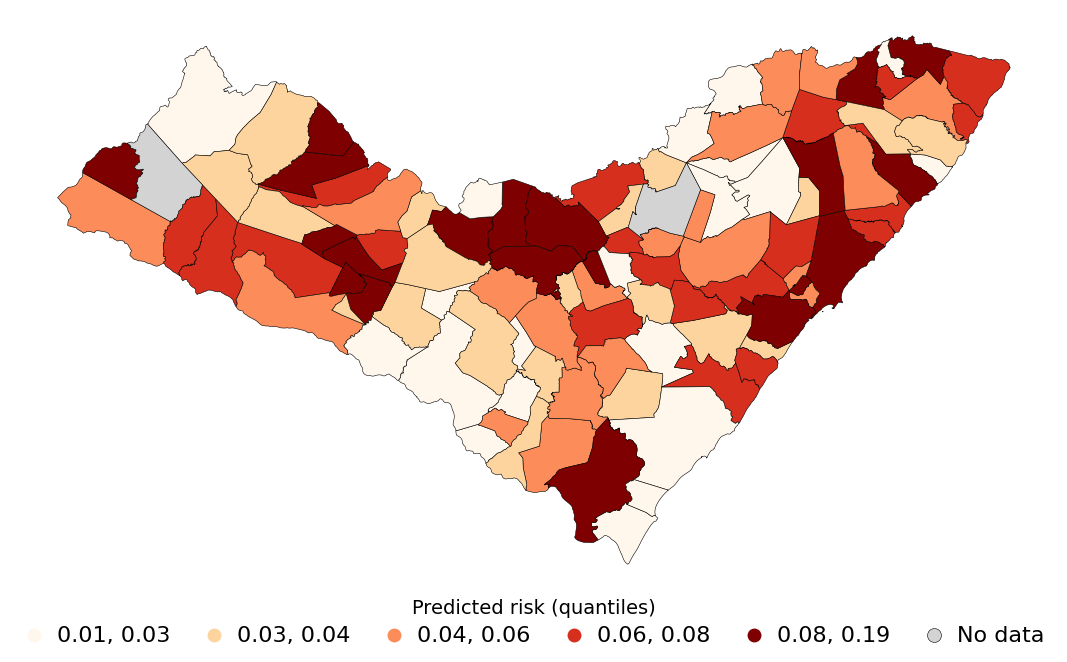

In [224]:

fig, ax = plt.subplots(figsize=(12, 10))  # MAIS LARGO

gdf_risco_2025.plot(
    column="risco_medio",
    cmap="OrRd",
    scheme="Quantiles",
    k=5,
    linewidth=0.4,
    edgecolor="black",
    legend=True,
    legend_kwds={
        "loc": "lower center",
        "bbox_to_anchor": (0.5, -0.12),
        "ncol": 6,  # 🔥 MUITO IMPORTANTE
        "title": "Predicted risk (quantiles)",
        "frameon": False,
        "handlelength": 1.2,
        "handleheight": 1.0
    },
    missing_kwds={
        "color": "lightgrey",
        "label": "No data"
    },
    ax=ax
)

# Fonte da legenda
leg = ax.get_legend()
leg.set_title("Predicted risk (quantiles)", prop={'size': 14})

for text in leg.get_texts():
    text.set_fontsize(16)

ax.axis("off")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "mapa_risco_2025.pdf"), bbox_inches="tight")
plt.show()

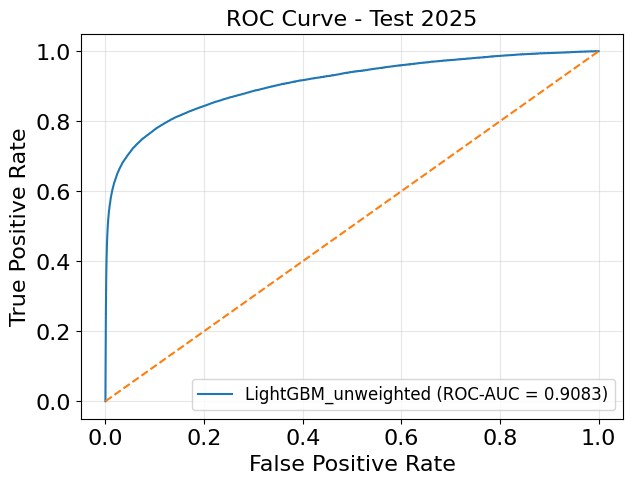

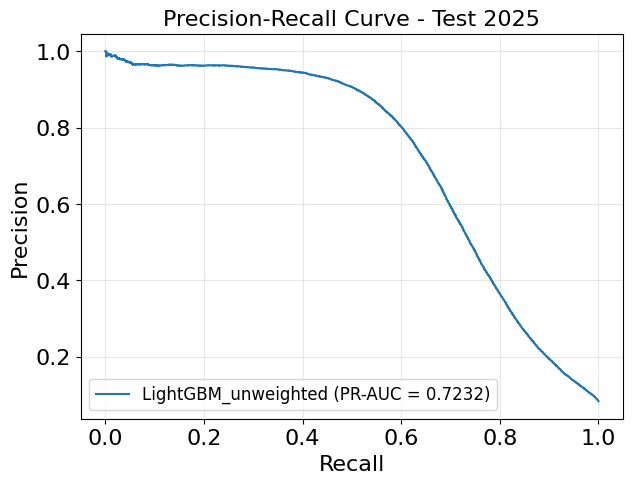

In [215]:
# ============================================================
# Célula 51 — Curvas ROC e PR NO TESTE
# ============================================================
# Objetivo:
# Gerar e salvar as curvas ROC e Precision-Recall do modelo final avaliado no teste temporal de 2025.
#
# Correção:
# Usar a variável consistente y_test_proba_final, que foi gerada na etapa de avaliação final.
# ============================================================

import os
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)

os.makedirs(OUTPUT_DIR, exist_ok=True)

plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "legend.fontsize": 12,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16
})

# ------------------------------------------------------------
# CURVA ROC
# ------------------------------------------------------------
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba_final)
auc_roc_test = roc_auc_score(y_test, y_test_proba_final)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr_test,
    tpr_test,
    label=f"{best_model_name}_{best_variant} (ROC-AUC = {auc_roc_test:.4f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Test 2025")
plt.legend()
plt.grid(False, alpha=0.3)

plt.savefig(
    os.path.join(OUTPUT_DIR, "roc_curve_test.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    os.path.join(OUTPUT_DIR, "roc_curve_test.pdf"),
    format="pdf",
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# CURVA PRECISION-RECALL
# ------------------------------------------------------------
precision_test, recall_test, _ = precision_recall_curve(y_test, y_test_proba_final)
auc_pr_test = average_precision_score(y_test, y_test_proba_final)

plt.figure(figsize=(7, 5))

plt.plot(
    recall_test,
    precision_test,
    label=f"{best_model_name}_{best_variant} (PR-AUC = {auc_pr_test:.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Test 2025")
plt.legend()
plt.grid(False, alpha=0.3)

plt.savefig(
    os.path.join(OUTPUT_DIR, "precision_recall_curve_test.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    os.path.join(OUTPUT_DIR, "precision_recall_curve_test.pdf"),
    format="pdf",
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ============================================================
# CÉLULA 52 — IMPORTÂNCIA DE VARIÁVEIS
# ============================================================
# Objetivo:
# Extrair a importância das variáveis do modelo final usando exatamente a base com a qual ele foi treinado.
#
# Correção:
# Não usar X_full_clipped se o treino final foi feito com X_full_final/X_full_common.
# ============================================================

feature_importance = get_feature_importance_df(final_model, X_full_final)

print("Top 20 variáveis mais importantes:")
display(feature_importance.head(20))

# Top 20 variáveis mais importantes:
# feature	importance
# 201	feat_pressao_alimentar	7962
# 6	d.cod_cta_energ_unid_consum_fam	6659
# 36	d.val_desp_energia_fam	6415
# 248	d.dat_cadastramento_fam_dia	5871
# 61	p.cod_ibge_munic_certid_pessoa	4776
# 247	d.dat_cadastramento_fam_mes	4716
# 246	d.dat_cadastramento_fam_ano	4673
# 0	d.cd_ibge	4664
# 37	d.val_desp_gas_fam	4558
# 198	feat_densidade_domiciliar	4537
# 63	p.cod_ibge_munic_nasc_pessoa	4420
# 86	d.dta_entrevista_fam_dia	4315
# 244	d.dat_atual_fam_dia	4268
# 33	d.val_desp_agua_esgoto_fam	4152
# 200	feat_renda_per_capita	3945
# 41	d.vlr_renda_total_fam	3936
# 34	d.val_desp_alimentacao_fam	3859
# 40	d.vlr_renda_media_fam	3567
# 243	d.dat_atual_fam_mes	3215
# 85	d.dta_entrevista_fam_mes	3135


Top 20 variáveis mais importantes:


,feature,importance
201,feat_pressao_alimentar,7962
6,d.cod_cta_energ_unid_consum_fam,6659
36,d.val_desp_energia_fam,6415
248,d.dat_cadastramento_fam_dia,5871
61,p.cod_ibge_munic_certid_pessoa,4776
247,d.dat_cadastramento_fam_mes,4716
246,d.dat_cadastramento_fam_ano,4673
0,d.cd_ibge,4664
37,d.val_desp_gas_fam,4558
198,feat_densidade_domiciliar,4537


In [212]:
# ============================================================
# CÉLULA 53 — SALVAR RESULTADOS FINAIS
# ============================================================
# Objetivo:
# Salvar os principais artefatos do notebook:
# - comparação na validação
# - métricas finais no teste de 2025
# - importância de variáveis
# - thresholds avaliados
# - modelo final treinado
# - resumo do melhor modelo
# ============================================================

import os
import json
import joblib
import pandas as pd

os.makedirs(OUTPUT_DIR, exist_ok=True)

comparison_models.to_csv(
    os.path.join(OUTPUT_DIR, "comparison_validation_models.csv"),
    index=False
)

comparison_weight_df.to_csv(
    os.path.join(OUTPUT_DIR, "comparison_lightgbm_weighting.csv"),
    index=False
)

thr_df_lgbm_weighted.to_csv(
    os.path.join(OUTPUT_DIR, "thresholds_lgbm_weighted.csv"),
    index=False
)

thr_df_lgbm_unweighted.to_csv(
    os.path.join(OUTPUT_DIR, "thresholds_lgbm_unweighted.csv"),
    index=False
)

thr_df_cat.to_csv(
    os.path.join(OUTPUT_DIR, "thresholds_catboost.csv"),
    index=False
)

pd.DataFrame([test_results_final]).to_csv(
    os.path.join(OUTPUT_DIR, "test_results_2025.csv"),
    index=False
)

feature_importance.to_csv(
    os.path.join(OUTPUT_DIR, "feature_importance_final.csv"),
    index=False
)

joblib.dump(
    final_model,
    os.path.join(OUTPUT_DIR, "final_model.pkl")
)

summary_info = {
    "best_model_name": best_model_name,
    "best_variant": best_variant,
    "best_scale_pos_weight": float(best_scale_pos_weight),
    "best_threshold": float(best_threshold)
}

with open(
    os.path.join(OUTPUT_DIR, "best_model_summary.json"),
    "w",
    encoding="utf-8"
) as f:
    json.dump(summary_info, f, ensure_ascii=False, indent=2)

print("Resultados finais salvos em:", OUTPUT_DIR)

Resultados finais salvos em: outputs/notebook2


In [ ]:
# ============================================================
# CÉLULA 18 — RESUMO FINAL
# ============================================================
# Objetivo:
# Apresentar um resumo consolidado do pipeline do Notebook 2, incluindo:
# - modelo escolhido
# - threshold ótimo
# - avaliação final no teste de 2025
#
# Correção:
# Garantir consistência com as variáveis utilizadas no restante do notebook (test_results_final).
# ============================================================

print("Resumo do Notebook 2")
print("=" * 60)
print("1. Artefatos do Notebook 1 carregados.")
print("2. LightGBM e CatBoost comparados na validação.")
print("3. LightGBM ajustado com tuning e early stopping.")
print(f"4. Variante final escolhida: {best_variant}")
print(f"5. scale_pos_weight final: {best_scale_pos_weight}")
print(f"6. Threshold final selecionado: {best_threshold:.2f}")
print("7. Modelo final treinado em todo 2024.")
print("8. Avaliação realizada no teste temporal de 2025.")
print("=" * 60)

display(pd.DataFrame([test_results_final]))


# Resumo do Notebook 2
# ============================================================
# 1. Artefatos do Notebook 1 carregados.
# 2. LightGBM e CatBoost comparados na validação.
# 3. LightGBM ajustado com tuning e early stopping.
# 4. Variante final escolhida: unweighted
# 5. scale_pos_weight final: 1.0
# 6. Threshold final selecionado: 0.09
# 7. Modelo final treinado em todo 2024.
# 8. Avaliação realizada no teste temporal de 2025.
# ============================================================
# dataset	modelo	threshold	accuracy	precision	recall	f1	f2	auc_roc	auc_pr	brier
# 0	test_2025	LightGBM_unweighted	0.09	0.883803	0.400372	0.783124	0.529855	0.657425	0.908349	0.723166	0.04878


Resumo do Notebook 2
1. Artefatos do Notebook 1 carregados.
2. LightGBM e CatBoost comparados na validação.
3. LightGBM ajustado com tuning e early stopping.
4. Variante final escolhida: unweighted
5. scale_pos_weight final: 1.0
6. Threshold final selecionado: 0.09
7. Modelo final treinado em todo 2024.
8. Avaliação realizada no teste temporal de 2025.


,dataset,modelo,threshold,accuracy,precision,recall,f1,f2,auc_roc,auc_pr,brier
0,test_2025,LightGBM_unweighted,0.09,0.883803,0.400372,0.783124,0.529855,0.657425,0.908349,0.723166,0.04878


## Metodologia

Nesta etapa do estudo, foi conduzida a comparação entre modelos avançados de classificação para predição do risco de insegurança alimentar a partir de dados administrativos harmonizados. O processo foi estruturado de forma temporalmente consistente, utilizando os dados de 2024 para treinamento e validação e reservando os dados de 2025 exclusivamente para o teste final. Essa estratégia buscou simular um cenário prospectivo realista, no qual o modelo é treinado com informações históricas e aplicado a observações futuras.

Inicialmente, foram comparados três modelos: LightGBM com ponderação de classe, LightGBM sem ponderação e CatBoost. Para garantir uma comparação justa, foi construída uma base comum com alinhamento das colunas entre os modelos e padronização do tratamento das variáveis categóricas. Em seguida, os modelos foram ajustados no conjunto de treino e avaliados no conjunto de validação por meio de métricas apropriadas a problemas de classificação desbalanceada, incluindo ROC-AUC, PR-AUC e Brier score.

Após essa etapa, foi realizado um processo adicional de ajuste de hiperparâmetros do LightGBM com `early stopping`, utilizando Average Precision como métrica de monitoramento. Essa escolha foi motivada pela baixa prevalência do evento de interesse, tornando a PR-AUC mais informativa do que métricas baseadas apenas em separação global. Com os melhores hiperparâmetros definidos, realizou-se uma comparação específica entre as variantes ponderada e não ponderada do LightGBM.

A variante sem ponderação (`unweighted`) apresentou o melhor desempenho na validação, combinando melhor capacidade discriminativa, melhor precisão-recall e menor erro probabilístico. A partir das probabilidades previstas na validação, foi selecionado o threshold ótimo segundo a métrica F2, priorizando recall sem desconsiderar precisão. O threshold final escolhido para a variante vencedora foi 0.09.

Na sequência, o modelo final foi re-treinado utilizando toda a base de 2024 e aplicado ao conjunto temporal de 2025. As probabilidades individuais preditas foram então agregadas ao nível municipal, permitindo a construção de indicadores espaciais de risco médio, prevalência observada e volume de registros por município. Esses resultados foram integrados ao shapefile municipal de Alagoas, possibilitando a geração de mapas coropléticos e rankings territoriais de risco.

Por fim, foi realizada a análise de importância de variáveis do modelo final, com o objetivo de identificar os fatores que mais contribuíram para a predição do risco.

## Resultados

A comparação inicial entre os modelos mostrou vantagem do LightGBM em relação ao CatBoost, especialmente quando avaliadas métricas mais adequadas a bases desbalanceadas. Após o tuning com `early stopping`, a comparação entre as variantes do LightGBM indicou superioridade da versão sem ponderação de classe. Essa variante foi, portanto, selecionada como modelo final.

No teste temporal de 2025, o modelo final `LightGBM_unweighted`, avaliado com threshold 0.09, apresentou desempenho elevado. A ROC-AUC foi de 0.9083 e a PR-AUC foi de 0.7232, indicando forte capacidade de discriminar e ranquear adequadamente os indivíduos segundo o risco predito. O Brier score de 0.0488 sugere também bom comportamento probabilístico das previsões.

Nas métricas dependentes de threshold, o modelo alcançou acurácia de 0.8838, precisão de 0.4004, recall de 0.7831, F1 de 0.5299 e F2 de 0.6574. Esse padrão é coerente com a estratégia adotada no estudo, que prioriza maior sensibilidade para identificação de casos vulneráveis, ainda que com perda moderada em precisão. Em problemas de triagem social e priorização de políticas públicas, esse comportamento é desejável, pois reduz a chance de subdetecção de famílias em situação de risco.

A agregação municipal das probabilidades preditas foi realizada para 100 municípios com registros válidos no conjunto de 2025. Dois municípios presentes no shapefile de Alagoas não possuíam observações correspondentes na base analisada e, por isso, permaneceram sem valor de risco associado no mapa final. A distribuição espacial revelou heterogeneidade territorial importante, com municípios do interior figurando entre os mais vulneráveis.

O ranking dos municípios com maior risco médio predito destacou, entre os primeiros colocados, Ouro Branco, Olho d’Água das Flores, Jacuípe, Limoeiro de Anadia e Pariconha. Esses resultados reforçam a presença de desigualdades territoriais persistentes no estado e mostram que a modelagem baseada em dados administrativos pode fornecer evidências úteis para vigilância social, focalização territorial e apoio à formulação de políticas públicas.

A análise das variáveis mais importantes indicou destaque para atributos relacionados à pressão alimentar, despesas com energia e outras dimensões materiais do domicílio. Esse achado reforça a natureza multidimensional da insegurança alimentar e sugere que a vulnerabilidade observada não depende apenas da renda declarada, mas também do equilíbrio entre recursos disponíveis, composição familiar e despesas essenciais.

## 2) Resultados 

### 2.1 Comparação dos modelos na validação

| dataset | modelo | threshold | accuracy | precision | recall | f1 | f2 | auc_roc | auc_pr | brier |
|---|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| validation | LightGBM_weighted | 0.50 | 0.713326 | 0.179289 | 0.698072 | 0.285302 | 0.442178 | 0.776717 | 0.257132 | 0.186389 |
| validation | LightGBM_unweighted | 0.09 | 0.712569 | 0.178103 | 0.693456 | 0.283416 | 0.439254 | 0.777651 | 0.313132 | 0.067456 |
| validation | CatBoost | 0.52 | 0.707828 | 0.170791 | 0.665219 | 0.271799 | 0.421295 | 0.756008 | 0.232653 | 0.202568 |

### 2.2 Diagnóstico de calibração prática das probabilidades

| Modelo | Média das probabilidades preditas | Observação |
|---|---:|---|
| Prevalência real na validação | 0.081967 | Referência |
| LightGBM_weighted | 0.409809 | Superestima fortemente a prevalência |
| LightGBM_unweighted | 0.081109 | Fica muito próximo da prevalência real |
| CatBoost | 0.433772 | Superestima fortemente a prevalência |

### 2.3 Decisão final do modelo

| Critério | Valor |
|---|---|
| Modelo final | LightGBM |
| Variante final | unweighted |
| `scale_pos_weight` | 1.0 |
| Threshold final | 0.09 |
| Base de treino final | Todo o ano de 2024 |
| Número final de features | 255 |

### 2.4 Hiperparâmetros selecionados

| Parâmetro | Valor |
|---|---:|
| learning_rate | 0.05 |
| num_leaves | 63 |
| min_child_samples | 20 |
| subsample | 0.8 |
| colsample_bytree | 0.8 |
| reg_alpha | 0.0 |
| reg_lambda | 1.0 |
| best_iteration | 2000 |

### 2.5 Resultado final no teste temporal de 2025

| dataset | modelo | threshold | accuracy | precision | recall | f1 | f2 | auc_roc | auc_pr | brier |
|---|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| test_2025 | LightGBM_unweighted | 0.09 | 0.883803 | 0.400372 | 0.783124 | 0.529855 | 0.657425 | 0.908349 | 0.723166 | 0.048780 |

### 2.6 Resumo das probabilidades preditas no teste

| Estatística | Valor |
|---|---:|
| count | 431036.000000 |
| mean | 0.063785 |
| std | 0.106802 |
| min | 0.000087 |
| 25% | 0.015107 |
| 50% | 0.031904 |
| 75% | 0.064999 |
| max | 0.970148 |

### 2.7 Agregação municipal em 2025

| Indicador | Valor |
|---|---:|
| Municípios no shapefile | 102 |
| Municípios com risco calculado | 100 |
| Municípios sem registros em 2025 | 2 |

### 2.8 Municípios sem risco associado

| CD_MUN | NM_MUN |
|---|---|
| 2700102 | Água Branca |
| 2709400 | Viçosa |



### 2.10 Top 10 municípios com menor risco predito

| cd_ibge | risco_medio | prevalencia_observada | n_familias |
|---|---:|---:|---:|
| 2701506 | 0.010739 | 0.011225 | 3118 |
| 2705002 | 0.013009 | 0.017### 2.9 Top 10 municípios com maior risco predito

| cd_ibge | risco_medio | prevalencia_observada | n_familias |
|---|---:|---:|---:|
| 2706109 | 0.193251 | 0.247283 | 4509 |
| 2705705 | 0.153804 | 0.223266 | 2768 |
| 2706422 | 0.136064 | 0.210724 | 1865 |
| 2707909 | 0.123042 | 0.163337 | 851 |
| 2705408 | 0.122011 | 0.157451 | 2134 |
| 2703403 | 0.120279 | 0.141482 | 2389 |
| 2703502 | 0.117910 | 0.218341 | 687 |
| 2702801 | 0.110511 | 0.130207 | 3049 |
| 2706703 | 0.108475 | 0.129903 | 10708 |
| 2704609 | 0.108090 | 0.134083 | 3289 |564 | 2562 |
| 2704104 | 0.015415 | 0.008499 | 3412 |
| 2709004 | 0.015724 | 0.007097 | 2677 |
| 2701357 | 0.016139 | 0.023791 | 1303 |
| 2708204 | 0.018109 | 0.006617 | 1209 |
| 2703700 | 0.020603 | 0.007445 | 2552 |
| 2705507 | 0.020833 | 0.027871 | 4485 |
| 2705309 | 0.021554 | 0.005805 | 1895 |
| 2708303 | 0.021560 | 0.032074 | 4739 |

### 2.11 Top 20 variáveis mais importantes do modelo final

| feature | importance |
|---|---:|
| feat_pressao_alimentar | 7962 |
| d.cod_cta_energ_unid_consum_fam | 6659 |
| d.val_desp_energia_fam | 6415 |
| d.dat_cadastramento_fam_dia | 5871 |
| p.cod_ibge_munic_certid_pessoa | 4776 |
| d.dat_cadastramento_fam_mes | 4716 |
| d.dat_cadastramento_fam_ano | 4673 |
| d.cd_ibge | 4664 |
| d.val_desp_gas_fam | 4558 |
| feat_densidade_domiciliar | 4537 |
| p.cod_ibge_munic_nasc_pessoa | 4420 |
| d.dta_entrevista_fam_dia | 4315 |
| d.dat_atual_fam_dia | 4268 |
| d.val_desp_agua_esgoto_fam | 4152 |
| feat_renda_per_capita | 3945 |
| d.vlr_renda_total_fam | 3936 |
| d.val_desp_alimentacao_fam | 3859 |
| d.vlr_renda_media_fam | 3567 |
| d.dat_atual_fam_mes | 3215 |
| d.dta_entrevista_fam_mes | 3135 |

---

## 3) Resultado final do arquivo 2

| Critério | Resultado final |
|---|---|
| Melhor modelo final | LightGBM_unweighted |
| Threshold final | 0.09 |
| Accuracy em 2025 | 0.883803 |
| Precision em 2025 | 0.400372 |
| Recall em 2025 | 0.783124 |
| F1 em 2025 | 0.529855 |
| F2 em 2025 | 0.657425 |
| ROC-AUC em 2025 | 0.908349 |
| PR-AUC em 2025 | 0.723166 |
| Brier em 2025 | 0.048780 |

### Leitura final
- O notebook mostra claramente que **usar peso de classe piorou a calibração prática**.
- O **LightGBM sem `scale_pos_weight`** foi a melhor escolha.
- O teste temporal de 2025 ficou forte em **ROC-AUC** e **PR-AUC**, com **recall alto**, coerente com um problema de triagem.
- A agregação municipal também ficou consistente, embora dois municípios do shapefile não tenham registros na base de 2025.